# Central Valley SR notebook

Sequential read order: setup -> configuration -> PRISM precipitation -> baseline NDVI -> SR pair generation -> audit and split -> model and training -> test evaluation -> artifact freeze. Steps are numbered 0-15 and run top to bottom.


# Step 0: Setup and environment


In [2]:
#install pinned versions when a requirements.txt is present, otherwise install
# unpinned and write the resolved versions out in Step 2.
import os, subprocess, sys
from pathlib import Path

_REQ = Path("requirements.txt")
if _REQ.exists():
    print("Installing from pinned requirements.txt")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", str(_REQ)], check=False)
else:
    print("No requirements.txt found - installing unpinned, versions are frozen in Step 2.")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "earthengine-api", "numpy", "pandas", "matplotlib",
                    "scikit-image", "scipy", "torch", "torchvision"], check=False)

Installing from pinned requirements.txt


In [3]:
from pathlib import Path
import os, sys, math, json, random, platform, io, time, urllib.request
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader


IN_COLAB = "google.colab" in sys.modules
colab_files = colab_drive = None
if IN_COLAB:
    from google.colab import files as colab_files      # noqa: F401
    from google.colab import drive as colab_drive      # noqa: F401

def maybe_mount_drive():
    """mounting Drive is opt-in and never required. Off Colab this is a no-op.
    Set CVSR_MOUNT_DRIVE=1 to mount; nothing downstream depends on a Drive path."""
    if not IN_COLAB or os.environ.get("CVSR_MOUNT_DRIVE", "0") != "1":
        return None
    colab_drive.mount("/content/drive")
    return Path("/content/drive/MyDrive")

DRIVE_ROOT = maybe_mount_drive()

# Optional extras (used if present, skipped cleanly if not)
try:
    from skimage.metrics import structural_similarity as ssim
    SKIMAGE_AVAILABLE = True
except Exception:
    SKIMAGE_AVAILABLE = False
try:
    from scipy import stats as scipy_stats
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False


try:
    display
except NameError:
    from IPython.display import display

print("Python      :", sys.version.split()[0], "|", platform.machine())
print("PyTorch     :", torch.__version__)
print("Environment :", "Colab" if IN_COLAB else "local Jupyter/Python")
print("Drive       :", DRIVE_ROOT if DRIVE_ROOT else "not mounted (not required)")
print("CUDA avail  :", torch.cuda.is_available())
print("MPS avail   :", torch.backends.mps.is_available() if hasattr(torch.backends, "mps") else False)
print("scikit-image:", SKIMAGE_AVAILABLE, "| scipy:", SCIPY_AVAILABLE)

Python      : 3.13.15 | x86_64
PyTorch     : 2.13.0+cu130
Environment : Colab
Drive       : not mounted (not required)
CUDA avail  : True
MPS avail   : False
scikit-image: True | scipy: True


In [ ]:
!pip install --upgrade sympy torch

In [4]:
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device: CUDA (Colab) -> MPS (Apple Silicon) -> CPU
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
def choose_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")
device = choose_device()
try:
    _ = torch.ones(2, device=device)
except Exception as e:
    print("Device smoke test failed, falling back to CPU:", e)
    device = torch.device("cpu")
print("Using device:", device)

Using device: cuda


In [5]:
import ee

# read the Earth Engine project from the environment so no private project ID
# is committed to the public repository. Set EE_PROJECT before running, e.g.
#   os.environ["EE_PROJECT"] = "my-ee-project"
EE_PROJECT = os.environ.get("EE_PROJECT", "bubbly-machine-481403-c5").strip()

EE_READY = False
if not EE_PROJECT:
    print("EE_PROJECT environment variable not set - Earth Engine NOT initialized.")
    print("That is fine if the baseline CSV and SR pairs are already cached on disk.")
else:
    try:
        ee.Initialize(project=EE_PROJECT)
        EE_READY = True
    except Exception:
        try:
            ee.Authenticate()
            ee.Initialize(project=EE_PROJECT)
            EE_READY = True
        except Exception as e:
            print("Earth Engine NOT initialized:", str(e)[:160])
            print("That is fine if the baseline CSV and SR pairs are already cached on disk.")
    if EE_READY:
        print("Earth Engine initialized.")

Earth Engine initialized.


# Step 1: Global configuration

Paths, study area, years, crop codes, SR settings, split rules, and the target crops excluded from the super-resolution claims. Every later step reads these values, so this is the only place to change them.


In [6]:
# ---------- Paths ----------
PROJECT_ROOT  = Path(os.environ.get("CVSR_PROJECT_ROOT", ".")).resolve()
PAIRS_DIR     = Path(os.environ.get("CVSR_PAIRS_DIR", PROJECT_ROOT / "data_pairs" / "sr_pairs_x4"))
RESULTS_DIR   = Path(os.environ.get("CVSR_RESULTS_DIR", PROJECT_ROOT / "results"))
FIG_DIR       = Path(os.environ.get("CVSR_FIG_DIR", PROJECT_ROOT / "figures" / "paper"))
CHECKPOINT_DIR= Path(os.environ.get("CVSR_CKPT_DIR", PROJECT_ROOT / "checkpoints"))
PAPER_DIR     = Path(os.environ.get("CVSR_PAPER_DIR", PROJECT_ROOT / "paper"))
FROZEN_DIR    = Path(os.environ.get("CVSR_FROZEN_DIR", PROJECT_ROOT / "frozen_artifacts"))
for d in [PAIRS_DIR, RESULTS_DIR, FIG_DIR, CHECKPOINT_DIR, PAPER_DIR, FROZEN_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ---------- explicit cache workflow ----------
# USE_CACHED_PAIRS=False  -> generate pairs into PAIRS_DIR (default; what a fresh user gets)
# USE_CACHED_PAIRS=True   -> read pairs from CACHED_PAIRS_DIR and skip generation entirely
USE_CACHED_PAIRS = os.environ.get("CVSR_USE_CACHED_PAIRS", "0") == "1"
_cached_env      = os.environ.get("CVSR_CACHED_PAIRS_DIR", "").strip()
CACHED_PAIRS_DIR = Path(_cached_env) if _cached_env else None
RESET_PAIRS      = False   # True wipes PAIRS_DIR before generating (requires confirmation)
AUTO_DOWNLOAD    = False   # True re-enables Colab auto-download of pair archives

if USE_CACHED_PAIRS and CACHED_PAIRS_DIR is None:
    raise ValueError("USE_CACHED_PAIRS is on but CVSR_CACHED_PAIRS_DIR is not set. "
                     "Point it at a directory of .npz pairs, or set USE_CACHED_PAIRS=False.")
# Every downstream read of the pair dataset goes through PAIRS_SOURCE.
PAIRS_SOURCE = CACHED_PAIRS_DIR if USE_CACHED_PAIRS else PAIRS_DIR

TRAIN_CSV = RESULTS_DIR / "train_files.csv"
VAL_CSV   = RESULTS_DIR / "val_files.csv"
TEST_CSV  = RESULTS_DIR / "test_files.csv"
BASELINE_CSV = RESULTS_DIR / "baseline_ndvi_all_crops.csv"

# ---------- Study area / period ----------
S2_SR_ID  = "COPERNICUS/S2_SR_HARMONIZED"
CDL_ID    = "USDA/NASS/CDL"
AOI_BBOX  = [-122.0, 38.0, -121.0, 38.5]          # Northern Central Valley / Sacramento-Delta
YEARS     = [2018, 2019, 2020, 2021, 2022]

CROP_CODES  = {"ALFALFA": 36, "ALMOND": 75, "CITRUS": 72, "GRAPES": 69}  # USDA CDL codes
CROP_CODE_LIST = list(CROP_CODES.values())

PRECIP_GROUP_HIGH = "higher-precipitation"
PRECIP_GROUP_LOW  = "lower-precipitation"

# ---------- Bands & NDVI indices ----------
SR_BANDS = ["B4", "B3", "B2", "B8"]   # Red, Green, Blue, NIR
RED_IDX  = 0                          # B4
NIR_IDX  = 3                          # B8

# ---------- Super-resolution settings ----------
SCALE           = 4
PATCH_SIZE_HR   = 128                 # divisible by SCALE
PATCH_SIZE_LR   = PATCH_SIZE_HR // SCALE
HR_SCALE_METERS = 10                  # S2 native res for these bands
CDL_SCALE       = 30                  # CDL native res
# this threshold applies to the UNION of the target crop classes, not to a single
# crop. A patch qualifies if >= 30% of its CDL pixels belong collectively to any target
# crop; the dominant crop is recorded separately in manifest_details.csv.
MIN_CROP_FRACTION = 0.3
# Separate, stricter threshold on the DOMINANT crop alone. MIN_CROP_FRACTION above is a
# constraint on the COMBINED target-crop cover, so a patch labelled "GRAPES" is only
# guaranteed to be >=30% target crops in total -- not >=30% grapes. Crop-broken-out SR
# results are therefore reported as dominant-crop-LABELLED, with a stricter view that keeps
# only patches whose own dominant crop clears this floor.
MIN_DOMINANT_CROP_FRACTION = 0.30
COMPOSITE_START_MONTHDAY = "06-01"    # growing-season composite window used for SR patches
COMPOSITE_END_MONTHDAY   = "09-30"

# ---------- Cloud masking / baseline NDVI ----------
MAX_CLOUD = 60                        # CLOUDY_PIXEL_PERCENTAGE ceiling
KEEP_SCL = (4, 5, 6, 7)
NDVI_REDUCE_SCALE = 60

# ---------- Train / validation / test split ----------
# Primary strategy: chronological hold-out by acquisition year. This prevents same-composite
# leakage -- nearby/overlapping 1.28 km patches drawn from the same growing-season composite
# could otherwise appear on both sides of a random split. Because the same geographic fields
# recur across years, it tests temporal generalisation within one region rather than full
# spatial independence.
SPLIT_TRAIN_YEARS  = [2018, 2019, 2020]
SPLIT_VAL_YEAR     = 2021
SPLIT_TEST_YEAR    = 2022
GEO_BLOCK_SIZE_DEG      = 0.02        # ~2.2 km blocks at this latitude, bigger than the 1.28 km patch
SPATIAL_SPLIT_FRACTIONS = {"train": 0.6, "val": 0.2, "test": 0.2}
MIN_TEST_CROP_COUNT     = 30
MIN_TEST_CROP_SHARE     = 0.05

# ---------- Target crops excluded from the super-resolution claims ----------
#No patches found in AOI
SR_CLAIM_EXCLUDED_CROPS = {"CITRUS"}
SR_CLAIM_EXCLUSION_REASON = {
    "CITRUS": "zero SR patches in the generated pair set (CDL citrus effectively absent "
              "from this AOI); retained in the baseline NDVI analysis only",
}

# ---------- Display-only figure settings ----------
DISPLAY_STRETCH  = (0.0, 0.30)
NDVI_VMIN, NDVI_VMAX = 0.0, 1.0
NDVI_ERR_VMAX    = 0.15
N_FIGURE_EXAMPLES = 3
EXAMPLE_SELECTION_RULE = "median_psnr"

# ---------- Run controls ----------
QUICK_TEST           = False
NUM_PATCHES_PER_YEAR = 3000
MIN_TOTAL_PAIRS      = 15000
MAX_ATTEMPTS_FACTOR  = 10

REGENERATE_BASELINE  = False
REGENERATE_PAIRS     = False
REGENERATE_MANIFEST_DETAILS = False
REGENERATE_PRECIP_LABELS    = False

assert PATCH_SIZE_HR % SCALE == 0, "PATCH_SIZE_HR must be divisible by SCALE"
AOI = ee.Geometry.Rectangle(AOI_BBOX) if EE_READY else None

print("Bands      :", SR_BANDS, "| RED_IDX", RED_IDX, "(B4) NIR_IDX", NIR_IDX, "(B8)")
print("Crops      :", CROP_CODES)
print("SR claims  : excluded ->", sorted(SR_CLAIM_EXCLUDED_CROPS) or "none",
      "| dominant-crop floor for crop-broken-out results:", MIN_DOMINANT_CROP_FRACTION)
print("SR         : x{} | HR {} | LR {}".format(SCALE, PATCH_SIZE_HR, PATCH_SIZE_LR))
print("Cloud/SCL  : CLOUDY_PIXEL_PERCENTAGE <=", MAX_CLOUD, "| KEEP_SCL", KEEP_SCL)
print("NDVI scale :", NDVI_REDUCE_SCALE, "m (regional reduction, not band resolution)")
print("Pairs read :", PAIRS_SOURCE, "(cached)" if USE_CACHED_PAIRS else "(generated here)")

Bands      : ['B4', 'B3', 'B2', 'B8'] | RED_IDX 0 (B4) NIR_IDX 3 (B8)
Crops      : {'ALFALFA': 36, 'ALMOND': 75, 'CITRUS': 72, 'GRAPES': 69}
SR claims  : excluded -> ['CITRUS'] | dominant-crop floor for crop-broken-out results: 0.3
SR         : x4 | HR 128 | LR 32
Cloud/SCL  : CLOUDY_PIXEL_PERCENTAGE <= 60 | KEEP_SCL (4, 5, 6, 7)
NDVI scale : 60 m (regional reduction, not band resolution)
Pairs read : /content/data_pairs/sr_pairs_x4 (generated here)


In [7]:
# Provenance manifest: records the exact configuration that produced every frozen output.
run_manifest = {
    "created_at": datetime.now().isoformat(timespec="seconds"),
    "project_root": str(PROJECT_ROOT),
    "python": sys.version.split()[0],
    "torch": torch.__version__,
    "seed": SEED,
    "device": str(device),
    "aoi_bbox": AOI_BBOX,
    "years": YEARS,
    "band_order": SR_BANDS,
    "red_idx": RED_IDX, "nir_idx": NIR_IDX,
    "cloudy_pixel_percentage_max": MAX_CLOUD,
    "keep_scl_classes": list(KEEP_SCL),
    "scl_7_note": "SCL 7 is unclassified/low-probability cloud, retained for coverage; "
                  "residual contamination disclosed as a limitation",
    "ndvi_reduce_scale_m": NDVI_REDUCE_SCALE,
    "baseline_ndvi_unit": "per-scene regional mean over crop-masked pixels (not monthly medians)",
    "sr_composite_window": f"{COMPOSITE_START_MONTHDAY} to {COMPOSITE_END_MONTHDAY} median composite",
    "crop_coverage_threshold": MIN_CROP_FRACTION,
    "crop_coverage_threshold_note": "applies to the union of target crop classes, not a single crop",
    "min_dominant_crop_fraction": MIN_DOMINANT_CROP_FRACTION,
    "sr_claim_excluded_crops": sorted(SR_CLAIM_EXCLUDED_CROPS),
    "sr_claim_exclusion_reasons": SR_CLAIM_EXCLUSION_REASON,
    "sr_absent_target_crops": None,   # filled in by Step 10 from the actual patch counts
    "patch_size_hr": PATCH_SIZE_HR, "patch_size_lr": PATCH_SIZE_LR, "scale_factor": SCALE,
    "use_cached_pairs": USE_CACHED_PAIRS,
    "pairs_source_dir": str(PAIRS_SOURCE),
    "baseline_data_source": None,
    "sr_pair_data_source": None,
    "paper_ready": False,
    "notes": [],
}
def save_manifest():
    with open(RESULTS_DIR / "run_manifest.json", "w") as f:
        json.dump(run_manifest, f, indent=2, default=str)
save_manifest()
print("Manifest initialised:", RESULTS_DIR / "run_manifest.json")

Manifest initialised: /content/results/run_manifest.json


# Step 2: Freeze package versions

Writes `requirements.txt` with the exact versions this run used. Re-running Step 0 with that file present installs the pinned set.


In [8]:
# freeze the exact package versions this run used.
import importlib.metadata as importlib_metadata

PKGS = ["earthengine-api", "numpy", "pandas", "matplotlib", "scikit-image",
        "scipy", "torch", "torchvision"]
lines_req = [f"# generated {datetime.now().isoformat(timespec='seconds')}",
             f"# python=={sys.version.split()[0]}"]
resolved = {}
for p in PKGS:
    try:
        v = importlib_metadata.version(p)
        resolved[p] = v
        lines_req.append(f"{p}=={v}")
    except importlib_metadata.PackageNotFoundError:
        lines_req.append(f"# {p} not installed in this environment")

req_path = PROJECT_ROOT / "requirements.txt"
req_path.write_text("\n".join(lines_req) + "\n")
run_manifest["package_versions"] = resolved
save_manifest()
print("Wrote", req_path)
print("\n".join(lines_req))
print("\nCommit this file. Re-running Step 0 with it present installs the pinned versions.")

Wrote /content/requirements.txt
# generated 2026-08-24T05:01:17
# python==3.13.15
earthengine-api==1.7.39
numpy==2.1.3
pandas==2.2.3
matplotlib==3.10.0
scikit-image==0.25.2
scipy==1.16.3
torch==2.13.0
torchvision==0.26.0+cu128

Commit this file. Re-running Step 0 with it present installs the pinned versions.


# Step 3: PRISM annual precipitation groups

Output: `results/annual_precipitation_labels.csv` with year, annual precipitation, the study-period mean, the anomaly, and a higher-/lower-precipitation group. These are relative groups, not a drought classification.


In [9]:
PRECIP_LABELS_CSV = RESULTS_DIR / "annual_precipitation_labels.csv"

def prism_annual_precip_mm(year, region, scale_m=4000):
    """Real annual precipitation (mm) for `year`, averaged over `region`, from PRISM ANm."""
    start = f"{year}-01-01"; end = f"{year}-12-31"
    annual_total = (ee.ImageCollection("OREGONSTATE/PRISM/ANm")
                    .filterDate(start, end).select("ppt").sum())
    val = annual_total.reduceRegion(reducer=ee.Reducer.mean(), geometry=region,
                                    scale=scale_m, bestEffort=True, maxPixels=int(1e9)).get("ppt")
    return float(ee.Number(val).getInfo())

if PRECIP_LABELS_CSV.exists() and not REGENERATE_PRECIP_LABELS:
    precip_df = pd.read_csv(PRECIP_LABELS_CSV)
    run_manifest["year_labels_source"] = f"cached_csv:{PRECIP_LABELS_CSV}"
    print("Loaded cached PRISM precipitation labels:", PRECIP_LABELS_CSV)
else:
    if not EE_READY:
        raise RuntimeError("annual_precipitation_labels.csv must be built from Earth Engine (PRISM), "
                           "but EE is not initialized. Set EE_PROJECT, or provide a cached CSV.")
    print("Computing real annual precipitation from PRISM for", YEARS, "...")
    rows = [{"year": y, "annual_precipitation_mm": prism_annual_precip_mm(y, AOI)} for y in YEARS]
    precip_df = pd.DataFrame(rows).sort_values("year").reset_index(drop=True)
    study_mean = float(precip_df["annual_precipitation_mm"].mean())
    precip_df["study_period_mean_mm"] = study_mean
    precip_df["anomaly_mm"] = precip_df["annual_precipitation_mm"] - study_mean
    precip_df["precip_group"] = np.where(
        precip_df["annual_precipitation_mm"] >= study_mean, PRECIP_GROUP_HIGH, PRECIP_GROUP_LOW)
    precip_df.to_csv(PRECIP_LABELS_CSV, index=False)
    run_manifest["year_labels_source"] = "earth_engine_real:PRISM/ANm"
    print("Saved PRISM annual precipitation groups:", PRECIP_LABELS_CSV)

# accept a legacy cached CSV that still uses wet/drought column names
if "precip_group" not in precip_df.columns and "label" in precip_df.columns:
    precip_df["precip_group"] = precip_df["label"].str.lower().map(LEGACY_LABEL_MAP)
if "study_period_mean_mm" not in precip_df.columns and "multi_year_mean_mm" in precip_df.columns:
    precip_df["study_period_mean_mm"] = precip_df["multi_year_mean_mm"]
if "anomaly_mm" not in precip_df.columns:
    precip_df["anomaly_mm"] = precip_df["annual_precipitation_mm"] - precip_df["study_period_mean_mm"]
precip_df = precip_df[["year", "annual_precipitation_mm", "study_period_mean_mm",
                       "anomaly_mm", "precip_group"]]
precip_df.to_csv(PRECIP_LABELS_CSV, index=False)

YEAR_GROUPS = dict(zip(precip_df["year"].astype(int), precip_df["precip_group"]))
run_manifest["year_precip_groups"] = YEAR_GROUPS
run_manifest["precip_grouping_method"] = (
    "annual PRISM precipitation vs the 2018-2022 study-period mean; relative grouping, "
    "not a climatological drought index")
save_manifest()
display(precip_df.round(2))
print("Year groups (derived from PRISM):", YEAR_GROUPS)
print("NOTE: these are relative precipitation groups, not a drought classification.")

Loaded cached PRISM precipitation labels: /content/results/annual_precipitation_labels.csv


,year,annual_precipitation_mm,study_period_mean_mm,anomaly_mm,precip_group
0,2018,436.52,384.83,51.69,higher-precipitation
1,2019,575.93,384.83,191.10,higher-precipitation
2,2020,171.51,384.83,-213.32,lower-precipitation
3,2021,466.31,384.83,81.48,higher-precipitation
4,2022,273.88,384.83,-110.95,lower-precipitation


Year groups (derived from PRISM): {2018: 'higher-precipitation', 2019: 'higher-precipitation', 2020: 'lower-precipitation', 2021: 'higher-precipitation', 2022: 'lower-precipitation'}
NOTE: these are relative precipitation groups, not a drought classification.


# Step 4: Earth Engine helpers

Cloud masking, CDL crop layers, and the growing-season composite used for SR patches.


In [10]:
def mask_s2_scl(img):
    """Cloud-mask Sentinel-2 L2A using the SCL band, keeping the classes in KEEP_SCL.

    KEEP_SCL = (4, 5, 6, 7): vegetation, bare soil, water, and unclassified.
    Class 7 is UNCLASSIFIED / LOW-PROBABILITY CLOUD -- it is not a confirmed clear-sky
    class. It is retained to preserve scene coverage, and the resulting residual
    contamination risk is disclosed in the manuscript limitations."""
    scl = img.select("SCL")
    good = scl.eq(int(KEEP_SCL[0]))
    for c in KEEP_SCL[1:]:
        good = good.Or(scl.eq(int(c)))
    return img.updateMask(good)

def get_cdl_image(year):
    """USDA CDL image for a given year."""
    img = ee.ImageCollection(CDL_ID).filter(ee.Filter.calendarRange(year, year, "year")).first()
    return ee.Image(img)

def cdl_crop_band_name(cdl_img):
    """CDL band name varies by year; pick 'cropland'/'classification' or the first band."""
    bands = cdl_img.bandNames()
    return ee.String(ee.Algorithms.If(bands.contains("cropland"), "cropland",
                ee.Algorithms.If(bands.contains("classification"), "classification", bands.get(0))))

def cdl_is_crop(year, codes):
    """Binary layer: 1 where CDL is in `codes`, else 0."""
    cdl  = get_cdl_image(year)
    band = cdl_crop_band_name(cdl)
    return cdl.select([band]).remap(list(codes), [1]*len(codes), 0).rename("is_crop")

def seasonal_composite(year):
    """Cloud-masked GROWING-SEASON (June 1 - September 30) median composite of the SR bands.

    SR patches are extracted from these seasonal composites -- they are NOT sampled
    year-round. Methods must describe the composite window, not a year-round sample."""
    start = f"{year}-{COMPOSITE_START_MONTHDAY}"; end = f"{year}-{COMPOSITE_END_MONTHDAY}"
    col = (ee.ImageCollection(S2_SR_ID)
           .filterBounds(AOI).filterDate(start, end)
           .filter(ee.Filter.lte("CLOUDY_PIXEL_PERCENTAGE", MAX_CLOUD))
           .map(mask_s2_scl))
    return col.select(SR_BANDS).median()

print("Earth Engine helpers ready." if EE_READY else "Earth Engine helpers defined (EE not initialized).")
print(f"Cloud filter: CLOUDY_PIXEL_PERCENTAGE <= {MAX_CLOUD} | SCL kept: {KEEP_SCL}")

Earth Engine helpers ready.
Cloud filter: CLOUDY_PIXEL_PERCENTAGE <= 60 | SCL kept: (4, 5, 6, 7)


# Step 5: Baseline crop-specific NDVI (Sentinel-2 + CDL)

Per-scene regional mean NDVI over each crop's CDL pixels. All four target crops appear here, citrus included: citrus has usable baseline NDVI scenes in this AOI even though it yields no SR patches later (see Step 10). Crops with insufficient annual coverage are reported as not analysable.


In [11]:
def ndvi_timeseries_for_crop(year, crop_code, scale=NDVI_REDUCE_SCALE):
    """Real per-scene mean NDVI over one crop's CDL pixels for one year."""
    crop_mask = cdl_is_crop(year, [crop_code]).selfMask()   # 1 on this crop, masked elsewhere
    start = f"{year}-01-01"; end = f"{year}-12-31"
    col = (ee.ImageCollection(S2_SR_ID)
           .filterBounds(AOI).filterDate(start, end)
           .filter(ee.Filter.lte("CLOUDY_PIXEL_PERCENTAGE", MAX_CLOUD))
           .map(mask_s2_scl))
    def add_ndvi(im):
        nir = im.select("B8"); red = im.select("B4")
        ndvi = nir.subtract(red).divide(nir.add(red).add(1e-6)).rename("NDVI")
        return im.addBands(ndvi).updateMask(crop_mask)
    col = col.map(add_ndvi)
    def reduce_one(im):
        v = im.select("NDVI").reduceRegion(
            reducer=ee.Reducer.mean(), geometry=AOI,
            scale=scale, bestEffort=True, maxPixels=int(1e9), tileScale=4
        ).get("NDVI")
        return ee.Feature(None, {"date": im.date().format("YYYY-MM-dd"), "ndvi_mean": v})
    fc = ee.FeatureCollection(col.map(reduce_one)).filter(ee.Filter.notNull(["ndvi_mean"]))
    feats = fc.getInfo()["features"]
    return [(f["properties"]["date"], f["properties"]["ndvi_mean"]) for f in feats]

In [13]:
if BASELINE_CSV.exists() and not REGENERATE_BASELINE:
    baseline_df = pd.read_csv(BASELINE_CSV, parse_dates=["date"])
    run_manifest["baseline_data_source"] = f"cached_csv:{BASELINE_CSV}"
    print("Loaded cached baseline NDVI:", BASELINE_CSV, "| rows:", len(baseline_df))
else:
    if not EE_READY:
        raise RuntimeError("Baseline NDVI must be built from Earth Engine, but EE is not initialized. "
                           "Set EE_PROJECT in Step 0, or provide a cached baseline_ndvi_all_crops.csv.")
    print("Building baseline NDVI from Earth Engine (this can take several minutes)...")
    rows = []
    for crop_name, code in CROP_CODES.items():
        crop_total = 0
        for year in YEARS:
            try:
                series = ndvi_timeseries_for_crop(year, code)
            except Exception as e:
                print(f"   {crop_name} {year}: EE error ({str(e)[:80]}) - skipped")
                continue
            for date_str, val in series:
                rows.append({"date": date_str, "year": year, "crop": crop_name,
                             "ndvi_mean": float(val),
                             "precip_group": YEAR_GROUPS.get(year, "unknown")})
            crop_total += len(series)
        print(f"   {crop_name}: {crop_total} scene-observations across {len(YEARS)} years")
    baseline_df = pd.DataFrame(rows)
    if baseline_df.empty:
        raise ValueError("No baseline NDVI observations returned. Check AOI/crop codes/EE access.")
    baseline_df["date"] = pd.to_datetime(baseline_df["date"])
    baseline_df.to_csv(BASELINE_CSV, index=False)
    run_manifest["baseline_data_source"] = f"earth_engine_real:{S2_SR_ID}+{CDL_ID}"
    print("Saved baseline NDVI:", BASELINE_CSV, "| rows:", len(baseline_df))

if "precip_group" not in baseline_df.columns and "label" in baseline_df.columns:
    baseline_df["precip_group"] = baseline_df["label"].str.lower().map(LEGACY_LABEL_MAP)
    print("Legacy wet/drought labels remapped to higher-/lower-precipitation.")
baseline_df["precip_group"] = baseline_df["year"].map(YEAR_GROUPS).fillna(baseline_df["precip_group"])
baseline_df = baseline_df.drop(columns=[c for c in ["label"] if c in baseline_df.columns])
baseline_df.to_csv(BASELINE_CSV, index=False)

run_manifest["baseline_n_scene_observations"] = int(len(baseline_df))
save_manifest()
display(baseline_df.head())
print("Crops present:", sorted(baseline_df["crop"].unique()))
print("Groups present:", sorted(baseline_df["precip_group"].dropna().unique()))
print("NOTE: each row is ONE Sentinel-2 scene's regional mean NDVI over that crop's CDL "
      f"pixels, reduced at {NDVI_REDUCE_SCALE} m. These are not monthly composites.")

Loaded cached baseline NDVI: /content/results/baseline_ndvi_all_crops.csv | rows: 1979


,date,year,crop,ndvi_mean,precip_group
0,2018-01-20,2018,ALFALFA,0.615916,higher-precipitation
1,2018-01-20,2018,ALFALFA,0.589594,higher-precipitation
2,2018-01-25,2018,ALFALFA,0.518265,higher-precipitation
3,2018-01-25,2018,ALFALFA,0.546258,higher-precipitation
4,2018-02-09,2018,ALFALFA,0.659210,higher-precipitation


Crops present: ['ALFALFA', 'ALMOND', 'CITRUS', 'GRAPES']
Groups present: ['higher-precipitation', 'lower-precipitation']
NOTE: each row is ONE Sentinel-2 scene's regional mean NDVI over that crop's CDL pixels, reduced at 60 m. These are not monthly composites.


# Step 6: Baseline NDVI summaries and figure


Outputs: `results/baseline_ndvi_summary.csv`, `results/baseline_ndvi_annual_means.csv`, `results/baseline_ndvi_annual_summary.csv`.


In [14]:
# Baseline NDVI summaries. TWO summaries are written and they are NOT interchangeable:
#
#   baseline_ndvi_summary.csv         scene-level. Every Sentinel-2 scene counts once, so a
#                                     year that happened to yield more usable scenes pulls
#                                     the group mean toward itself. Scene counts differ
#                                     substantially across years and crops here, so this
#                                     table is kept for reference ONLY.
#   baseline_ndvi_annual_summary.csv  annual means first, then the higher-/lower-
#                                     precipitation comparison across those annual values.
#                                     Each year carries equal weight regardless of how many
#                                     scenes it contributed. THIS is the comparison the
#                                     manuscript reports.
#
# Both are descriptive. repeated scenes from a single AOI
# are temporally autocorrelated, and five successive years are not independent replicates
# either.

# ---------- (a) scene-level summary: reference only, scene-weighted ----------
scene_rows = []
for crop, sub in baseline_df.groupby("crop"):
    high = sub[sub["precip_group"].eq(PRECIP_GROUP_HIGH)]["ndvi_mean"].dropna()
    low  = sub[sub["precip_group"].eq(PRECIP_GROUP_LOW)]["ndvi_mean"].dropna()
    high_mean = high.mean() if len(high) else np.nan
    low_mean  = low.mean()  if len(low)  else np.nan
    diff = low_mean - high_mean
    pct  = 100 * diff / high_mean if (high_mean and not np.isnan(high_mean)) else np.nan
    scene_rows.append({
        "crop": crop,
        "higher_precip_mean_ndvi": high_mean,
        "higher_precip_sd_ndvi": high.std(ddof=1) if len(high) > 1 else np.nan,
        "lower_precip_mean_ndvi": low_mean,
        "lower_precip_sd_ndvi": low.std(ddof=1) if len(low) > 1 else np.nan,
        "lower_minus_higher": diff,
        "percent_change": pct,
        "n_higher_precip_scenes": int(len(high)),
        "n_lower_precip_scenes": int(len(low)),
        "weighting": "scene-level (reference only, not the reported comparison)",
    })
baseline_summary = pd.DataFrame(scene_rows).sort_values("crop").reset_index(drop=True)
baseline_summary.to_csv(RESULTS_DIR / "baseline_ndvi_summary.csv", index=False)
print("(a) SCENE-level summary - reference only, weighted by number of scenes per year:")
display(baseline_summary.round(4))

# ---------- (b) annual means: one row per crop-year ----------
annual_means = (baseline_df.groupby(["crop", "year", "precip_group"])["ndvi_mean"]
                .agg(annual_mean_ndvi="mean", n_scenes="size").reset_index())
annual_means.to_csv(RESULTS_DIR / "baseline_ndvi_annual_means.csv", index=False)

# How uneven is the scene sampling? This is precisely why (c) rather than (a) is reported.
scene_spread = (annual_means.groupby("crop")["n_scenes"]
                .agg(min_scenes_in_a_year="min", max_scenes_in_a_year="max",
                     total_scenes="sum").reset_index())
scene_spread["max_over_min_ratio"] = (scene_spread["max_scenes_in_a_year"] /
                                      scene_spread["min_scenes_in_a_year"].replace(0, np.nan))
print("\n(b) Scenes contributing to each crop-year. Uneven counts across years are the "
      "reason the precipitation comparison uses annual means:")
display(scene_spread.round(2))

# ---------- (c) precipitation comparison over the ANNUAL means (reported) ----------
annual_rows = []
for crop, sub in annual_means.groupby("crop"):
    high = sub[sub["precip_group"].eq(PRECIP_GROUP_HIGH)]
    low  = sub[sub["precip_group"].eq(PRECIP_GROUP_LOW)]
    h_vals, l_vals = high["annual_mean_ndvi"], low["annual_mean_ndvi"]
    h_mean = float(h_vals.mean()) if len(h_vals) else np.nan
    l_mean = float(l_vals.mean()) if len(l_vals) else np.nan
    diff = (l_mean - h_mean) if (len(h_vals) and len(l_vals)) else np.nan
    pct = (100 * diff / h_mean) if (np.isfinite(diff) and h_mean not in (0, np.nan)
                                    and np.isfinite(h_mean)) else np.nan
    annual_rows.append({
        "crop": crop,
        "higher_precip_annual_mean": h_mean,
        "higher_precip_sd_across_years": float(h_vals.std(ddof=1)) if len(h_vals) > 1 else np.nan,
        "lower_precip_annual_mean": l_mean,
        "lower_precip_sd_across_years": float(l_vals.std(ddof=1)) if len(l_vals) > 1 else np.nan,
        "difference": diff,
        "percent_change": pct,
        "n_years_higher": int(len(h_vals)), "n_years_lower": int(len(l_vals)),
        "n_scenes_higher": int(high["n_scenes"].sum()), "n_scenes_lower": int(low["n_scenes"].sum()),
        "weighting": "annual means, each year weighted equally (reported comparison)",
    })
baseline_annual_summary = pd.DataFrame(annual_rows).sort_values("crop").reset_index(drop=True)
baseline_annual_summary.to_csv(RESULTS_DIR / "baseline_ndvi_annual_summary.csv", index=False)
print("\n(c) ANNUAL summary - the reported higher- vs lower-precipitation comparison:")
display(baseline_annual_summary.round(4))

run_manifest["baseline_inferential_tests"] = (
    "none - removed; scene-level observations are temporally autocorrelated and successive "
    "years are not independent replicates. Descriptive means, SDs, differences and counts only.")
run_manifest["baseline_precipitation_comparison_basis"] = (
    "annual means (results/baseline_ndvi_annual_summary.csv); each year weighted equally, "
    "so years contributing more Sentinel-2 scenes do not dominate the group mean")
run_manifest["baseline_scene_level_summary_role"] = (
    "reference only (results/baseline_ndvi_summary.csv); scene-weighted, not the reported "
    "precipitation comparison")
save_manifest()

# A crop needs at least this many years on BOTH sides before its annual difference means
# anything. With 3 higher- and 2 lower-precipitation years in 2018-2022 this is the most any
# crop can offer, and it is still a small-n descriptive comparison.
MIN_YEARS_PER_PRECIP_GROUP = 2
weak = baseline_annual_summary[
    (baseline_annual_summary["n_years_higher"] < MIN_YEARS_PER_PRECIP_GROUP) |
    (baseline_annual_summary["n_years_lower"] < MIN_YEARS_PER_PRECIP_GROUP)]["crop"].tolist()
if weak:
    print("\nNOTE: insufficient annual coverage in this AOI to interpret:", weak,
          "- report these as not analysable rather than drawing conclusions.")
else:
    print(f"\nEvery crop has >= {MIN_YEARS_PER_PRECIP_GROUP} years on both sides of the "
          "precipitation split (3 higher / 2 lower). This is still a small-n descriptive "
          "comparison, not a test.")

print("Report the ANNUAL numbers as descriptive group differences. Do not attach p-values "
      "to them, and do not use the words wet, drought, or stress detection when describing "
      "them. Citrus stays in this baseline analysis; it is excluded only from the SR results.")


(a) SCENE-level summary - reference only, weighted by number of scenes per year:


,crop,higher_precip_mean_ndvi,higher_precip_sd_ndvi,lower_precip_mean_ndvi,lower_precip_sd_ndvi,lower_minus_higher,percent_change,n_higher_precip_scenes,n_lower_precip_scenes,weighting
0,ALFALFA,0.5671,0.0945,0.5540,0.0656,-0.0131,-2.3133,310,228,"scene-level (reference only, not the reported ..."
1,ALMOND,0.4781,0.0851,0.4590,0.0683,-0.0191,-3.9981,309,228,"scene-level (reference only, not the reported ..."
2,CITRUS,0.5315,0.1639,0.4387,0.1640,-0.0928,-17.4657,148,218,"scene-level (reference only, not the reported ..."
3,GRAPES,0.4292,0.0947,0.3823,0.1345,-0.0470,-10.9407,310,228,"scene-level (reference only, not the reported ..."



(b) Scenes contributing to each crop-year. Uneven counts across years are the reason the precipitation comparison uses annual means:


,crop,min_scenes_in_a_year,max_scenes_in_a_year,total_scenes,max_over_min_ratio
0,ALFALFA,99,118,538,1.19
1,ALMOND,98,118,537,1.20
2,CITRUS,44,114,366,2.59
3,GRAPES,99,118,538,1.19



(c) ANNUAL summary - the reported higher- vs lower-precipitation comparison:


,crop,higher_precip_annual_mean,higher_precip_sd_across_years,lower_precip_annual_mean,lower_precip_sd_across_years,difference,percent_change,n_years_higher,n_years_lower,n_scenes_higher,n_scenes_lower,weighting
0,ALFALFA,0.5676,0.0220,0.5540,0.0013,-0.0136,-2.3905,3,2,310,228,"annual means, each year weighted equally (repo..."
1,ALMOND,0.4790,0.0245,0.4602,0.0460,-0.0189,-3.9434,3,2,309,228,"annual means, each year weighted equally (repo..."
2,CITRUS,0.5396,0.1274,0.4401,0.0443,-0.0994,-18.4281,3,2,148,218,"annual means, each year weighted equally (repo..."
3,GRAPES,0.4299,0.0167,0.3836,0.0544,-0.0462,-10.7574,3,2,310,228,"annual means, each year weighted equally (repo..."



Every crop has >= 2 years on both sides of the precipitation split (3 higher / 2 lower). This is still a small-n descriptive comparison, not a test.
Report the ANNUAL numbers as descriptive group differences. Do not attach p-values to them, and do not use the words wet, drought, or stress detection when describing them. Citrus stays in this baseline analysis; it is excluded only from the SR results.


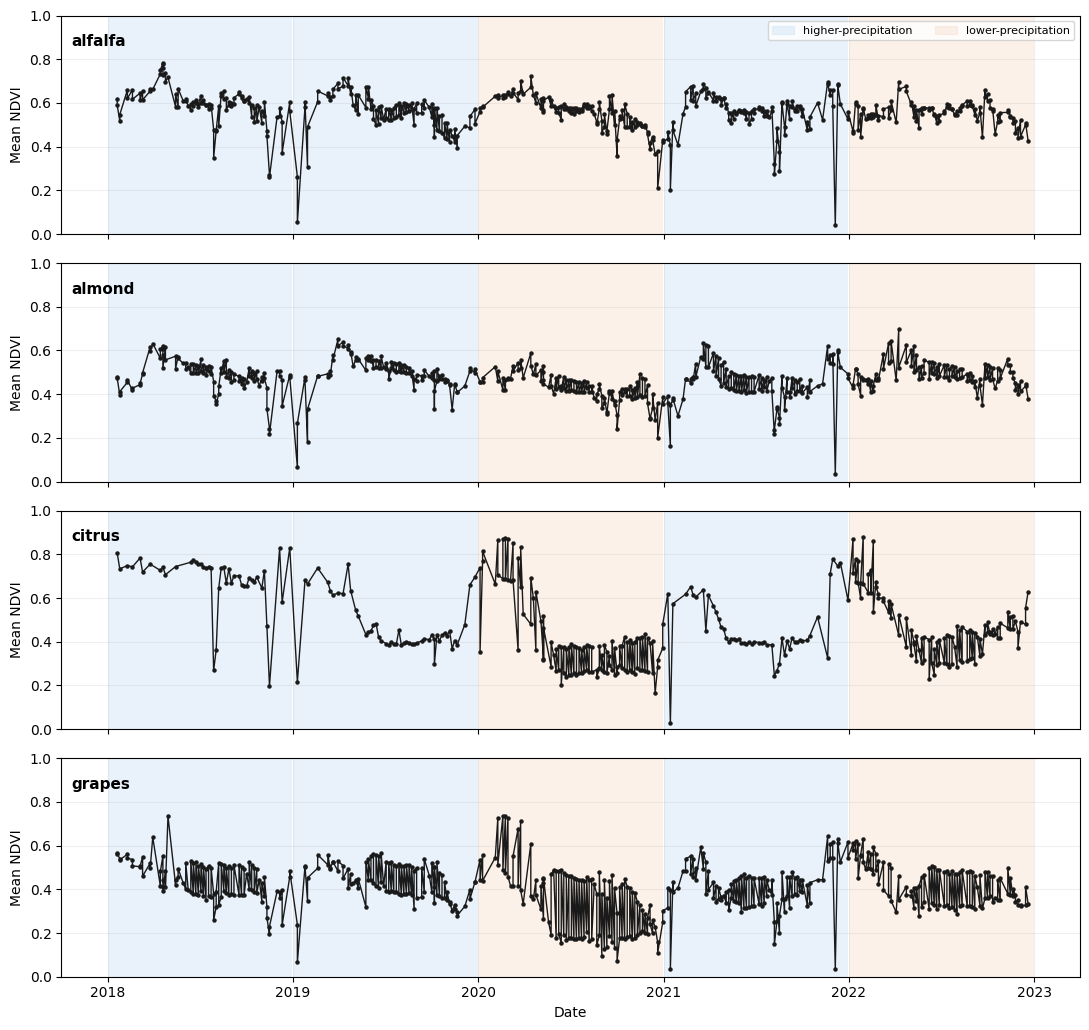

Saved: /content/figures/paper/figure_baseline_ndvi_by_crop.png
Caption note: the black trace is the per-scene regional mean NDVI; background shading marks each year's precipitation group. No line segment spans a data gap.


In [15]:
import matplotlib.patches as mpatches

GROUP_COLORS = {PRECIP_GROUP_HIGH: "#cfe3f7", PRECIP_GROUP_LOW: "#f7e0cf"}

def plot_baseline_ndvi(df, precip_table, out_path):
    crops = sorted(df["crop"].unique())
    fig, axes = plt.subplots(len(crops), 1, figsize=(11, 2.6*len(crops)), sharex=True)
    if len(crops) == 1:
        axes = [axes]
    for ax, crop in zip(axes, crops):
        for _, r in precip_table.iterrows():
            ax.axvspan(pd.Timestamp(f"{int(r['year'])}-01-01"),
                       pd.Timestamp(f"{int(r['year'])}-12-31"),
                       color=GROUP_COLORS.get(r["precip_group"], "#eeeeee"),
                       alpha=0.45, lw=0, zorder=0)
        sub = df[df["crop"] == crop].sort_values("date")
        ax.plot(sub["date"], sub["ndvi_mean"], color="#1a1a1a", lw=1.0,
                marker="o", ms=2.2, zorder=2)
        ax.set_ylabel("Mean NDVI"); ax.set_ylim(0, 1)
        ax.text(0.01, 0.86, crop.lower(), transform=ax.transAxes, fontsize=11, fontweight="bold")
        ax.grid(True, alpha=0.2, zorder=1)
    handles = [mpatches.Patch(color=c, alpha=0.45, label=g) for g, c in GROUP_COLORS.items()]
    axes[0].legend(handles=handles, loc="upper right", fontsize=8, ncol=2)
    axes[-1].set_xlabel("Date")
    fig.tight_layout()
    fig.savefig(out_path, dpi=250, bbox_inches="tight"); plt.show()

baseline_fig = FIG_DIR / "figure_baseline_ndvi_by_crop.png"
plot_baseline_ndvi(baseline_df, precip_df, baseline_fig)
print("Saved:", baseline_fig)
print("Caption note: the black trace is the per-scene regional mean NDVI; background shading "
      "marks each year's precipitation group. No line segment spans a data gap.")

# Step 7: Build SR training pairs

Saves LR/HR arrays (band order `[B4, B3, B2, B8]`) plus per-patch metadata into `data_pairs/sr_pairs_x4/`. Generation is resumable and skipped entirely when at least 15,000 pairs already exist and `REGENERATE_PAIRS=False`.


In [16]:
# ---- pure-Python helpers for pair building ----
def structured_npy_to_hwc(arr, bands):
    return np.stack([arr[b].astype(np.float32) for b in bands], axis=-1)

def to_reflectance(hr_raw):
    return np.clip(hr_raw.astype(np.float32) / 10000.0, 0.0, 1.0)

def downsample_area_exact(hr, scale):
    H, W, C = hr.shape
    assert H % scale == 0 and W % scale == 0
    return hr.reshape(H//scale, scale, W//scale, scale, C).mean(axis=(1, 3)).astype(np.float32)

def is_valid_patch(hr_raw):
    if not np.isfinite(hr_raw).all():
        return False
    if float((hr_raw == 0).all(axis=-1).mean()) > 0.05:
        return False
    if float(hr_raw.std()) < 1e-6:
        return False
    return True

def pair_filename(year, lon, lat):
    """Deterministic name so the same coordinate always maps to the same file."""
    return f"S2_{year}_{lon:.5f}_{lat:.5f}.npz".replace("-", "m")

def download_hr_patch(image, lon, lat, size_px, scale_m, bands):
    half_m = (size_px * scale_m) / 2.0
    region = ee.Geometry.Point([lon, lat]).buffer(half_m).bounds()
    try:
        url = image.getDownloadURL({"bands": bands, "region": region,
                                    "dimensions": f"{size_px}x{size_px}", "format": "NPY"})
        raw = urllib.request.urlopen(url, timeout=120).read()
        return structured_npy_to_hwc(np.load(io.BytesIO(raw)), bands)
    except Exception as e:
        print("   download failed:", str(e)[:100]); return None

def crop_candidates(year, n, seed):
    """Random points on target-crop pixels, filtered by COLLECTIVE target-crop coverage.

    The MIN_CROP_FRACTION threshold applies to the UNION of all target crop classes within
    the patch window, not to a single crop. The dominant target crop and its own fraction
    are recorded per patch at save time. Returns (lon, lat, coverage, dom_code, dom_frac)."""
    is_crop = cdl_is_crop(year, CROP_CODE_LIST)
    pts = is_crop.stratifiedSample(numPoints=0, classBand="is_crop", region=AOI, scale=CDL_SCALE,
                                   classValues=[1], classPoints=[n], seed=seed, tileScale=16,
                                   geometries=True)
    half_m = (PATCH_SIZE_HR * HR_SCALE_METERS) / 2.0
    cdl_img = get_cdl_image(year)
    cdl_band = cdl_crop_band_name(cdl_img)

    def add_stats(feat):
        win = feat.geometry().buffer(half_m).bounds()
        # collective target-crop coverage
        frac = is_crop.reduceRegion(reducer=ee.Reducer.mean(), geometry=win, scale=CDL_SCALE,
                                    maxPixels=int(1e8), tileScale=16).get("is_crop")
        # full class histogram, so the dominant crop can be resolved without a second pass
        hist = cdl_img.select([cdl_band]).reduceRegion(
            reducer=ee.Reducer.frequencyHistogram(), geometry=win, scale=CDL_SCALE,
            maxPixels=int(1e8), tileScale=16).get(cdl_band)
        return feat.set("crop_frac", frac).set("cdl_hist", hist)

    feats = pts.map(add_stats).getInfo()["features"]
    out = []
    for f in feats:
        props = f["properties"]
        fr = props.get("crop_frac")
        if fr is None or fr < MIN_CROP_FRACTION:
            continue
        hist = props.get("cdl_hist") or {}
        counts = {int(k): v for k, v in hist.items()}
        total = sum(counts.values())
        target_counts = {c: v for c, v in counts.items() if c in CROP_CODE_LIST}
        if target_counts and total:
            dom_code = max(target_counts, key=target_counts.get)
            dom_frac = target_counts[dom_code] / total
        else:
            dom_code, dom_frac = -1, float("nan")
        lon, lat = f["geometry"]["coordinates"][0], f["geometry"]["coordinates"][1]
        out.append((lon, lat, float(fr), int(dom_code), float(dom_frac)))
    return out

def code_to_crop_name(code):
    return next((name for name, c in CROP_CODES.items() if c == code), None)

def save_pair(path, lr, hr, meta):
    """Item 7: write geolocation and crop metadata INTO the .npz at generation time, so
    none of it has to be recomputed later through thousands of Earth Engine requests."""
    np.savez_compressed(
        path,
        lr=lr.astype(np.float32), hr=hr.astype(np.float32),
        year=np.int32(meta["year"]),
        lon=np.float64(meta["lon"]), lat=np.float64(meta["lat"]),
        crop_coverage=np.float32(meta["crop_coverage"]),
        dominant_crop_code=np.int32(meta["dominant_crop_code"]),
        dominant_crop_fraction=np.float32(meta["dominant_crop_fraction"]),
        band_order=np.array(SR_BANDS),
        scale_factor=np.int32(SCALE),
        composite_window=np.array([COMPOSITE_START_MONTHDAY, COMPOSITE_END_MONTHDAY]),
    )

def read_pair_meta(path):
    """Return the metadata stored at generation time, or {} for older metadata-free files."""
    try:
        with np.load(path, allow_pickle=False) as d:
            if "year" not in d.files:
                return {}
            code = int(d["dominant_crop_code"])
            return {
                "year": int(d["year"]), "longitude": float(d["lon"]), "latitude": float(d["lat"]),
                "crop_fraction": float(d["crop_coverage"]),
                "dominant_crop_code": code,
                "crop_label": code_to_crop_name(code),
                "dominant_crop_fraction": float(d["dominant_crop_fraction"]),
                "band_order": ",".join([str(b) for b in d["band_order"]]),
            }
    except Exception:
        return {}

print("Pair-building helpers ready.")

Pair-building helpers ready.


In [17]:
# generation is resumable, never auto-downloads, rejects duplicate
# coordinates before counting a save, and stores per-patch metadata in the .npz.
import shutil

if USE_CACHED_PAIRS:
    n_cached = len(list(PAIRS_SOURCE.glob("*.npz")))
    if n_cached == 0:
        raise FileNotFoundError(f"USE_CACHED_PAIRS=True but no .npz files in {PAIRS_SOURCE}.")
    run_manifest["sr_pair_data_source"] = f"user_supplied_cache:{PAIRS_SOURCE} ({n_cached} files)"
    print(f"USE_CACHED_PAIRS=True - using {n_cached} pairs from {PAIRS_SOURCE}. Generation skipped.")
else:
    existing_files = sorted(PAIRS_DIR.glob("*.npz"))
    have_enough = len(existing_files) >= MIN_TOTAL_PAIRS

    if RESET_PAIRS:
        if os.environ.get("CVSR_CONFIRM_RESET", "0") != "1":
            raise RuntimeError(f"RESET_PAIRS=True would delete {len(existing_files)} pairs. "
                               "Set CVSR_CONFIRM_RESET=1 to confirm, or leave RESET_PAIRS=False "
                               "to resume generation instead.")
        for f in existing_files:
            f.unlink()
        existing_files = []
        print("RESET_PAIRS: pair directory cleared.")

    if have_enough and not REGENERATE_PAIRS and not RESET_PAIRS:
        run_manifest["sr_pair_data_source"] = f"cached_real_npz:{PAIRS_DIR} ({len(existing_files)} files)"
        print(f"Found {len(existing_files)} pairs in {PAIRS_DIR} - skipping generation.")
    else:
        if not EE_READY:
            raise RuntimeError("SR pairs must be built from Earth Engine, but EE is not initialized. "
                               "Set EE_PROJECT, or point CVSR_CACHED_PAIRS_DIR at existing pairs.")

        # ---- resume state: what is already on disk, keyed by coordinate ----
        seen_coords_gen = set()
        for f in PAIRS_DIR.glob("*.npz"):
            m = read_pair_meta(f)
            if m:
                seen_coords_gen.add((m["year"], round(m["longitude"], 5), round(m["latitude"], 5)))
        saved_by_year = {}
        for f in PAIRS_DIR.glob("*.npz"):
            try:
                yr = int(f.name.split("_")[1])
                saved_by_year[yr] = saved_by_year.get(yr, 0) + 1
            except Exception:
                pass
        print(f"Resuming: {len(list(PAIRS_DIR.glob('*.npz')))} pairs already on disk "
              f"({saved_by_year}). Existing files are kept, not deleted.")

        n_saved_total = n_dup_rejected = n_resume_skipped = 0

        for year in YEARS:
            print(f"\n=== Year {year} ===")
            composite = seasonal_composite(year)
            saved_for_year = int(saved_by_year.get(year, 0))
            if saved_for_year >= NUM_PATCHES_PER_YEAR:
                print(f"   already have {saved_for_year}/{NUM_PATCHES_PER_YEAR} for {year} - skipping.")
                continue
            attempt_seed_offset = 0
            MAX_CANDIDATES_PER_EE_CALL = 4500
            total_candidates_sampled_for_year = 0

            while saved_for_year < NUM_PATCHES_PER_YEAR and \
                  total_candidates_sampled_for_year < (NUM_PATCHES_PER_YEAR * MAX_ATTEMPTS_FACTOR):

                num_to_request = min(MAX_CANDIDATES_PER_EE_CALL,
                                     (NUM_PATCHES_PER_YEAR * MAX_ATTEMPTS_FACTOR)
                                     - total_candidates_sampled_for_year)
                if num_to_request <= 0:
                    break

                cands_batch = crop_candidates(year, num_to_request,
                                              seed=SEED + year + attempt_seed_offset)
                attempt_seed_offset += 1
                total_candidates_sampled_for_year += len(cands_batch)
                if not cands_batch:
                    print(f"   no more candidates for {year}. Saved {saved_for_year}/{NUM_PATCHES_PER_YEAR}")
                    break
                print(f"   {len(cands_batch)} candidates this batch (total sampled "
                      f"{total_candidates_sampled_for_year})")

                for lon, lat, coverage, dom_code, dom_frac in cands_batch:
                    if saved_for_year >= NUM_PATCHES_PER_YEAR:
                        break

                    # reject duplicates before any download or counter increment
                    coord_key = (year, round(lon, 5), round(lat, 5))
                    if coord_key in seen_coords_gen:
                        n_dup_rejected += 1
                        continue
                    out_path = PAIRS_DIR / pair_filename(year, lon, lat)
                    if out_path.exists():
                        seen_coords_gen.add(coord_key)
                        n_resume_skipped += 1
                        continue

                    hr_raw = download_hr_patch(composite, lon, lat, PATCH_SIZE_HR,
                                               HR_SCALE_METERS, SR_BANDS)
                    if hr_raw is None or hr_raw.shape != (PATCH_SIZE_HR, PATCH_SIZE_HR, len(SR_BANDS)):
                        continue
                    if not is_valid_patch(hr_raw):
                        continue

                    hr = to_reflectance(hr_raw)
                    lr = downsample_area_exact(hr, SCALE)
                    save_pair(out_path, lr, hr, {
                        "year": year, "lon": lon, "lat": lat,
                        "crop_coverage": coverage,
                        "dominant_crop_code": dom_code,
                        "dominant_crop_fraction": dom_frac,
                    })
                    seen_coords_gen.add(coord_key)
                    saved_for_year += 1
                    n_saved_total += 1
                    if saved_for_year % 100 == 0:
                        print(f"   saved {saved_for_year}/{NUM_PATCHES_PER_YEAR} for {year}")
                    time.sleep(0.05)

            print(f"   -> {saved_for_year} patches for {year} (target {NUM_PATCHES_PER_YEAR})")

        n_on_disk = len(list(PAIRS_DIR.glob("*.npz")))
        print(f"\nNew this run: {n_saved_total} | duplicate coords rejected: {n_dup_rejected} "
              f"| already-present skipped: {n_resume_skipped}")
        print(f"Total pairs on disk: {n_on_disk}")
        if n_on_disk < MIN_TOTAL_PAIRS:
            print(f"WARNING: {n_on_disk} < {MIN_TOTAL_PAIRS}. Re-run this cell to resume "
                  "(existing files are preserved), or lower MIN_CROP_FRACTION.")
        run_manifest["sr_pair_data_source"] = f"earth_engine_real:{S2_SR_ID}"
        run_manifest["pairs_new_this_run"] = n_saved_total
        run_manifest["pairs_duplicate_coords_rejected"] = n_dup_rejected

def archive_pairs(tag="pairs"):
    """Zip the pair directory on request. Downloads only if AUTO_DOWNLOAD is on in Colab."""
    base = str(PROJECT_ROOT / f"sr_pairs_x4_{tag}")
    shutil.make_archive(base, "zip", PAIRS_DIR)
    print("Archive written:", base + ".zip")
    if AUTO_DOWNLOAD and IN_COLAB:
        colab_files.download(base + ".zip")
    return base + ".zip"

save_manifest()

Found 15000 pairs in /content/data_pairs/sr_pairs_x4 - skipping generation.


# Step 8: Load pairs, audit, and detect scale

Checks filenames, coordinates, finiteness, reflectance range, band order, and that each LR array really is the 4x area-average of its HR target. Only patches passing every check reach the splits.


In [18]:
# Optional: unpack a previously archived pair set instead of regenerating.
# Point CVSR_PAIRS_ARCHIVE at a .zip anywhere
# (a Drive path, a local file, a mounted volume) and re-run this cell.
_archive = os.environ.get("CVSR_PAIRS_ARCHIVE", "").strip()
if not _archive:
    print("No CVSR_PAIRS_ARCHIVE set - skipping import. "
          "Pairs will be read from:", PAIRS_SOURCE)
else:
    src = Path(_archive)
    if not src.exists():
        raise FileNotFoundError(f"CVSR_PAIRS_ARCHIVE points at {src}, which does not exist.")
    import zipfile
    before = len(list(PAIRS_DIR.glob("*.npz")))
    with zipfile.ZipFile(src) as zf:
        zf.extractall(PAIRS_DIR)
    after = len(list(PAIRS_DIR.glob("*.npz")))
    print(f"Extracted {src} -> {PAIRS_DIR} ({before} -> {after} pairs)")

No CVSR_PAIRS_ARCHIVE set - skipping import. Pairs will be read from: /content/data_pairs/sr_pairs_x4


In [19]:
import re

pair_files = sorted(PAIRS_SOURCE.glob("*.npz"))
assert len(pair_files) > 0, f"No .npz pairs in {PAIRS_SOURCE}. Run Step 7 or set CVSR_CACHED_PAIRS_DIR."

# file names are written as f"S2_{year}_{lon:.5f}_{lat:.5f}.npz".replace("-", "m")
FNAME_RE = re.compile(r"^S2_(\d+)_(m?[\d.]+)_(m?[\d.]+)\.npz$")

def parse_pair_filename(fname):
    """Recover (year, lon, lat) from the naming convention; (None, None, None) if unmatched.
    Used only as a fallback for pairs written before metadata was stored in the .npz."""
    m = FNAME_RE.match(fname)
    if not m:
        return None, None, None
    def _num(tok):
        return -float(tok[1:]) if tok.startswith("m") else float(tok)
    return int(m.group(1)), _num(m.group(2)), _num(m.group(3))

def read_pair(path):
    d = np.load(path)
    return d["lr"].astype(np.float32), d["hr"].astype(np.float32)

# --- extended data-infrastructure audit ---
# Checks: unique filenames/coordinates, missing/non-finite values, reflectance range,
# 4-band order plausibility, and LR == 4x area-average of HR within tolerance.
audit_rows, valid_files = [], []
seen_coords = {}
LR_HR_ATOL = 1e-4  # numerical tolerance for LR == 4x area-average(HR)

for p in pair_files:
    fname = p.name
    meta = read_pair_meta(p)
    if meta:
        year, lon, lat = meta["year"], meta["longitude"], meta["latitude"]
    else:
        year, lon, lat = parse_pair_filename(fname)
    row = {"file": fname, "year": year, "longitude": lon, "latitude": lat}
    try:
        lr, hr = read_pair(p)
        lh, lw, lc = lr.shape; hh, hw, hc = hr.shape
        sh, sw = hh / lh, hw / lw
        shape_ok = lr.ndim == 3 and hr.ndim == 3 and abs(sh - sw) < 1e-6 and lc == hc

        finite_ok = bool(np.isfinite(lr).all() and np.isfinite(hr).all())
        n_nonfinite = int((~np.isfinite(hr)).sum() + (~np.isfinite(lr)).sum())

        reflect_ok = bool((hr.min() >= -1e-6) and (hr.max() <= 1.0 + 1e-6) and
                          (lr.min() >= -1e-6) and (lr.max() <= 1.0 + 1e-6))

        bands_ok = (hc == len(SR_BANDS)) and (lc == len(SR_BANDS))
        band_order_plausible = bool(hr[..., NIR_IDX].mean() > hr[..., RED_IDX].mean()) if bands_ok else False

        if finite_ok and shape_ok:
            lr_expected = downsample_area_exact(hr, int(round(sh)))
            lr_match = bool(np.allclose(lr, lr_expected, atol=LR_HR_ATOL))
            lr_max_abs_err = float(np.max(np.abs(lr - lr_expected)))
        else:
            lr_match = False
            lr_max_abs_err = np.nan

        valid = (
            shape_ok
            and finite_ok
            and reflect_ok
            and bands_ok
            and lr_match
        )
        row.update({
            "lr_shape": str(lr.shape), "hr_shape": str(hr.shape), "scale_h": sh, "channels": hc,
            "shape_ok": shape_ok, "finite_ok": finite_ok, "n_nonfinite": n_nonfinite,
            "reflectance_ok": reflect_ok, "hr_min": float(hr.min()), "hr_max": float(hr.max()),
            "bands_ok": bands_ok, "band_order_plausible": band_order_plausible,
            "lr_matches_4x_avg_hr": lr_match, "lr_max_abs_err_vs_4x_avg": lr_max_abs_err,
            "has_stored_metadata": bool(meta),
            "valid": bool(valid),
        })
        if valid:
            valid_files.append(fname)
    except Exception as e:
        row.update({"error": str(e), "valid": False})
    audit_rows.append(row)

    if lon is not None and lat is not None:
        seen_coords.setdefault((round(lon, 5), round(lat, 5)), []).append(fname)

audit_df = pd.DataFrame(audit_rows)
audit_df.to_csv(RESULTS_DIR / "data_audit.csv", index=False)
assert valid_files, "No valid LR/HR pairs found."

n_files = len(pair_files)
n_unique_files = audit_df["file"].nunique()
assert n_unique_files == n_files, f"Duplicate filenames on disk: {n_files - n_unique_files} repeats."

dup_coord_groups = {k: v for k, v in seen_coords.items() if len(v) > 1}
n_unique_coords = len(seen_coords)

band_order_ok_frac = float(audit_df["band_order_plausible"].mean()) if "band_order_plausible" in audit_df else np.nan
lr_match_frac = float(audit_df["lr_matches_4x_avg_hr"].mean()) if "lr_matches_4x_avg_hr" in audit_df else np.nan
reflect_ok_frac = float(audit_df["reflectance_ok"].mean()) if "reflectance_ok" in audit_df else np.nan
total_nonfinite = int(audit_df["n_nonfinite"].sum()) if "n_nonfinite" in audit_df else np.nan
year_counts = audit_df["year"].value_counts(dropna=False).sort_index()

n_failed = int((~audit_df["valid"].astype(bool)).sum())
n_failed_lr = int((~audit_df["lr_matches_4x_avg_hr"].fillna(False).astype(bool)).sum())

DETECTED_SCALE = int(round(audit_df[audit_df["valid"]]["scale_h"].round(6).mode().iloc[0]))
s_lr, s_hr = read_pair(PAIRS_SOURCE / valid_files[0])
IN_CHANNELS = s_hr.shape[-1]; HR_PATCH = s_hr.shape[0]; LR_PATCH = s_lr.shape[0]

run_manifest.update({
    "detected_scale": DETECTED_SCALE, "input_channels": IN_CHANNELS,
    "hr_patch": HR_PATCH, "lr_patch": LR_PATCH, "num_pair_files": n_files,
    "audit_n_unique_filenames": n_unique_files, "audit_n_unique_coordinates": n_unique_coords,
    "audit_n_duplicate_coordinate_groups": len(dup_coord_groups),
    "audit_band_order_plausible_fraction": band_order_ok_frac,
    "audit_lr_matches_4x_avg_hr_fraction": lr_match_frac,
    "audit_reflectance_in_range_fraction": reflect_ok_frac,
    "audit_total_nonfinite_values": total_nonfinite,
    "audit_n_invalid_patches": n_failed,
    "audit_lr_match_enforced_in_validity": True,
    "audit_n_valid_patches": len(valid_files),
})
save_manifest()

print("Detected scale:", DETECTED_SCALE, "| channels:", IN_CHANNELS, "| HR", HR_PATCH, "| LR", LR_PATCH)
print(f"Files on disk: {n_files} | unique filenames: {n_unique_files} | unique coordinates: {n_unique_coords}")
print(f"Duplicate-coordinate groups: {len(dup_coord_groups)}"
      + (f" (e.g. {list(dup_coord_groups.items())[0]})" if dup_coord_groups else ""))
print(f"Non-finite values found: {total_nonfinite}")
print(f"Reflectance in [0,1] for {reflect_ok_frac*100:.1f}% of patches")
print(f"4-band order plausible (mean NIR > mean RED) for {band_order_ok_frac*100:.1f}% of patches")
print(f"LR matches 4x area-average of HR (atol={LR_HR_ATOL}) for {lr_match_frac*100:.1f}% of patches")
print(f"Patches with metadata stored at generation time: "
      f"{int(audit_df['has_stored_metadata'].sum()) if 'has_stored_metadata' in audit_df else 0}/{n_files}")
print("Patch counts by year:")
print(year_counts.to_string())
print(f"\nVALID (all checks incl. lr_match): {len(valid_files)}/{n_files} | failed: {n_failed}")
if n_failed_lr:
    print(f"IMPORTANT: {n_failed_lr} patches fail lr_match and are now excluded from the splits. "
          "Report this count in Methods -- with the old code they were silently included.")
if IN_CHANNELS <= max(RED_IDX, NIR_IDX):
    print("WARNING: not enough channels for NDVI (need NIR at index", NIR_IDX, ").")

Detected scale: 4 | channels: 4 | HR 128 | LR 32
Files on disk: 15000 | unique filenames: 15000 | unique coordinates: 14919
Duplicate-coordinate groups: 81 (e.g. ((-121.11569, 38.19378), ['S2_2018_m121.11569_38.19378.npz', 'S2_2022_m121.11569_38.19378.npz']))
Non-finite values found: 0
Reflectance in [0,1] for 100.0% of patches
4-band order plausible (mean NIR > mean RED) for 100.0% of patches
LR matches 4x area-average of HR (atol=0.0001) for 100.0% of patches
Patches with metadata stored at generation time: 15000/15000
Patch counts by year:
year
2018    3000
2019    3000
2020    3000
2021    3000
2022    3000

VALID (all checks incl. lr_match): 15000/15000 | failed: 0


# Step 9: Per-patch manifest details

One row per SR pair: file, year, longitude, latitude, combined target-crop fraction, dominant crop label, the dominant crop's own fraction of the patch, band order, and LR/HR shapes. Values come from metadata stored at generation time, falling back to a cached CSV and then to a single Earth Engine lookup; they are never guessed.


In [20]:
MANIFEST_DETAILS_CSV = RESULTS_DIR / "manifest_details.csv"

def crop_fraction_and_label(lon, lat, year, size_px=PATCH_SIZE_HR, scale_m=HR_SCALE_METERS):

    if not EE_READY or lon is None or lat is None or year is None:
        return np.nan, None, np.nan
    try:
        cdl = get_cdl_image(year)
        band = cdl_crop_band_name(cdl)
        half_m = (size_px * scale_m) / 2.0
        win = ee.Geometry.Point([lon, lat]).buffer(half_m).bounds()
        hist = cdl.select([band]).reduceRegion(
            reducer=ee.Reducer.frequencyHistogram(), geometry=win,
            scale=CDL_SCALE, maxPixels=int(1e8), tileScale=8,
        ).get(band).getInfo() or {}
        total = sum(hist.values())
        if total == 0:
            return np.nan, None, np.nan
        code_counts = {int(k): v for k, v in hist.items()}
        crop_total = sum(v for c, v in code_counts.items() if c in CROP_CODE_LIST)
        frac = crop_total / total
        target_counts = {c: v for c, v in code_counts.items() if c in CROP_CODE_LIST}
        label, dom_frac = None, np.nan
        if target_counts:
            dominant_code = max(target_counts, key=target_counts.get)
            label = code_to_crop_name(dominant_code)
            dom_frac = target_counts[dominant_code] / total
        return float(frac), label, float(dom_frac)
    except Exception as e:
        print("   crop-info lookup failed for", lon, lat, year, ":", str(e)[:80])
        return np.nan, None, np.nan

if MANIFEST_DETAILS_CSV.exists() and not REGENERATE_MANIFEST_DETAILS:
    prior_manifest_df = pd.read_csv(MANIFEST_DETAILS_CSV)
else:
    prior_manifest_df = pd.DataFrame(columns=["file"])
prior_lookup = prior_manifest_df.set_index("file").to_dict("index") if len(prior_manifest_df) else {}

manifest_rows = []
n_from_npz = n_from_cache = n_from_ee = 0
for _, arow in audit_df.iterrows():
    fname = arow["file"]
    stored = read_pair_meta(PAIRS_SOURCE / fname)

    if stored:                                   # metadata written at generation time
        n_from_npz += 1
        row = {
            "file": fname, "year": stored["year"],
            "longitude": stored["longitude"], "latitude": stored["latitude"],
            "crop_fraction": stored["crop_fraction"],
            "crop_label": stored["crop_label"],
            "dominant_crop_fraction": stored["dominant_crop_fraction"],
            "band_order": stored["band_order"],
            "metadata_source": "npz_at_generation",
        }
    elif fname in prior_lookup and not REGENERATE_MANIFEST_DETAILS:
        n_from_cache += 1
        row = dict(prior_lookup[fname]); row["file"] = fname
        row.setdefault("metadata_source", "cached_csv")
    else:                                        # legacy pair: one EE lookup, then cached
        n_from_ee += 1
        year, lon, lat = parse_pair_filename(fname)
        frac, label, dom_frac = crop_fraction_and_label(lon, lat, year)
        row = {
            "file": fname, "year": year, "longitude": lon, "latitude": lat,
            "crop_fraction": frac, "crop_label": label, "dominant_crop_fraction": dom_frac,
            "band_order": ",".join(SR_BANDS), "metadata_source": "earth_engine_lookup",
        }
    row["lr_shape"] = arow.get("lr_shape")
    row["hr_shape"] = arow.get("hr_shape")
    row["valid"] = arow.get("valid")
    manifest_rows.append(row)

manifest_details_df = pd.DataFrame(manifest_rows)
manifest_details_df.to_csv(MANIFEST_DETAILS_CSV, index=False)
run_manifest["manifest_details_csv"] = str(MANIFEST_DETAILS_CSV)
run_manifest["manifest_details_rows"] = len(manifest_details_df)
run_manifest["manifest_metadata_from_npz"] = n_from_npz
run_manifest["manifest_metadata_from_ee_lookup"] = n_from_ee
save_manifest()

display(manifest_details_df.head())
print("Saved per-patch manifest:", MANIFEST_DETAILS_CSV, "| rows:", len(manifest_details_df))
print(f"Metadata source - stored in .npz: {n_from_npz} | cached CSV: {n_from_cache} | "
      f"Earth Engine lookup: {n_from_ee}")
if n_from_ee:
    print("NOTE: those EE lookups are cached in manifest_details.csv and will not repeat. "
          "Pairs generated by the current Step 7 carry their metadata already.")
if manifest_details_df["crop_label"].isna().all():
    print("NOTE: crop_label is entirely empty - Earth Engine was unavailable and the pairs "
          "predate stored metadata. Re-run with EE_PROJECT set to populate it.")

,file,year,longitude,latitude,crop_fraction,crop_label,dominant_crop_fraction,band_order,metadata_source,lr_shape,hr_shape,valid
0,S2_2018_m121.01664_38.01323.npz,2018,-121.016638,38.013229,0.333122,GRAPES,0.333122,"B4,B3,B2,B8",npz_at_generation,"(32, 32, 4)","(128, 128, 4)",True
1,S2_2018_m121.02196_38.06867.npz,2018,-121.021964,38.068667,0.349188,GRAPES,0.349188,"B4,B3,B2,B8",npz_at_generation,"(32, 32, 4)","(128, 128, 4)",True
2,S2_2018_m121.02367_38.03449.npz,2018,-121.023668,38.034491,0.354210,GRAPES,0.354210,"B4,B3,B2,B8",npz_at_generation,"(32, 32, 4)","(128, 128, 4)",True
3,S2_2018_m121.02412_38.03578.npz,2018,-121.024117,38.035783,0.321733,GRAPES,0.321733,"B4,B3,B2,B8",npz_at_generation,"(32, 32, 4)","(128, 128, 4)",True
4,S2_2018_m121.02512_38.01090.npz,2018,-121.025119,38.010901,0.583197,GRAPES,0.582093,"B4,B3,B2,B8",npz_at_generation,"(32, 32, 4)","(128, 128, 4)",True


Saved per-patch manifest: /content/results/manifest_details.csv | rows: 15000
Metadata source - stored in .npz: 15000 | cached CSV: 0 | Earth Engine lookup: 0


# Step 10: Target-crop representation and split decision

Two separate questions, because they have different answers:

1. **Is any target crop absent from the dataset entirely?** Zero patches cannot be fixed by any split strategy. Such a crop is reported explicitly and must be declared in `SR_CLAIM_EXCLUDED_CROPS`, which removes it from every SR claim.
2. **Is any present crop too thin in the candidate test year (2022)?** That would make its chronological test metric meaningless, so the notebook falls back to a grouped spatial-block split -- never an unrestricted random per-patch split.


In [21]:
# ---------------------------------------------------------------------------------------
# Target-crop representation check.
#
# TWO distinct failure modes are checked separately, because they have different remedies:
#
#   (1) ABSENT crop        zero patches anywhere in the pair set. No split strategy can
#                          manufacture test patches for it. The crop must be dropped from
#                          every SR claim and declared in SR_CLAIM_EXCLUDED_CROPS.
#   (2) UNDER-REPRESENTED  present in the dataset overall, but too thin in the candidate
#                          test year. Fixable: fall back to the grouped spatial-block split.
#
# The earlier version of this cell only tested (2), and did so behind a `total_for_crop > 0`
# guard. A crop with zero patches skipped the test entirely and the notebook then announced
# that every target crop was adequately represented -- which was false for citrus, absent
# from all 15,000 patches. Absence is now detected first and reported on its own terms.
# ---------------------------------------------------------------------------------------
TARGET_CROPS = sorted(CROP_CODES.keys())
n_patches_total = len(manifest_details_df)

# crop_fraction floor: this is the COMBINED cover of all target crops in the patch
low_frac = manifest_details_df[manifest_details_df["crop_fraction"].notna() &
                               (manifest_details_df["crop_fraction"] < MIN_CROP_FRACTION)]
print(f"Patches below the combined target-crop floor ({MIN_CROP_FRACTION}): "
      f"{len(low_frac)} / {n_patches_total}")

# How much of a patch is its OWN dominant crop? crop_label is a dominant-crop label, and
# MIN_CROP_FRACTION says nothing about it, so this is reported separately.
if "dominant_crop_fraction" in manifest_details_df.columns:
    dom_frac_all = pd.to_numeric(manifest_details_df["dominant_crop_fraction"], errors="coerce")
    n_dom_ok = int((dom_frac_all >= MIN_DOMINANT_CROP_FRACTION).sum())
    print(f"Patches whose DOMINANT crop alone covers >= {MIN_DOMINANT_CROP_FRACTION:.0%} of "
          f"the patch: {n_dom_ok} / {n_patches_total} "
          f"(median dominant-crop fraction {dom_frac_all.median():.3f})")
else:
    dom_frac_all = pd.Series(dtype=float)
    print("WARNING: manifest_details.csv has no dominant_crop_fraction column. Crop-labelled "
          "SR results cannot be filtered by dominant-crop cover - regenerate the manifest.")

# ---- crop / year counts across the WHOLE dataset, absent target crops shown as zeros ----
year_crop_counts = (manifest_details_df.groupby(["year", "crop_label"], dropna=False)
                    .size().reset_index(name="count"))
year_crop_counts.to_csv(RESULTS_DIR / "patch_counts_by_year_crop.csv", index=False)
pivot_year_crop = year_crop_counts.pivot(index="year", columns="crop_label",
                                         values="count").fillna(0).astype(int)
for crop_name in TARGET_CROPS:                       # absent crops must be visible as 0
    if crop_name not in pivot_year_crop.columns:
        pivot_year_crop[crop_name] = 0
ordered_cols = [c for c in TARGET_CROPS if c in pivot_year_crop.columns]
ordered_cols += [c for c in pivot_year_crop.columns if c not in ordered_cols]
pivot_year_crop = pivot_year_crop[ordered_cols]
display(pivot_year_crop)

crop_totals = manifest_details_df["crop_label"].value_counts(dropna=False)
crop_patch_totals = {c: int(crop_totals.get(c, 0)) for c in TARGET_CROPS}
absent_target_crops  = [c for c in TARGET_CROPS if crop_patch_totals[c] == 0]
present_target_crops = [c for c in TARGET_CROPS if crop_patch_totals[c] > 0]

labelled_totals = crop_totals[[i for i in crop_totals.index if isinstance(i, str)]]
dominant_crop = labelled_totals.idxmax() if len(labelled_totals) else None
dominant_share = float(labelled_totals.max() / labelled_totals.sum()) if len(labelled_totals) else float("nan")
print("Total patches by dominant-crop label:")
print(crop_totals.to_string())
for crop_name in absent_target_crops:
    print(f"  {crop_name}: 0")
if dominant_crop is not None and dominant_share > 0.5:
    print(f"NOTE: the dataset is dominated by {dominant_crop} ({dominant_share*100:.1f}% of all "
          "labelled patches). Do not describe the SR dataset as balanced across crops without "
          "qualifying this.")

# ---- (1) ABSENT target crops -----------------------------------------------------------
print("\n" + "=" * 70)
undeclared_absent = [c for c in absent_target_crops if c not in SR_CLAIM_EXCLUDED_CROPS]
if absent_target_crops:
    print(f"ABSENT TARGET CROPS: {absent_target_crops}")
    for crop_name in absent_target_crops:
        print(f"  - {crop_name}: 0 patches in the entire {n_patches_total}-patch SR dataset, "
              f"in every year including the candidate test year {SPLIT_TEST_YEAR}.")
        if crop_name in SR_CLAIM_EXCLUDED_CROPS:
            print("      Declared in SR_CLAIM_EXCLUDED_CROPS: "
                  f"{SR_CLAIM_EXCLUSION_REASON.get(crop_name, 'NO REASON RECORDED')}")
        else:
            print("      NOT declared in SR_CLAIM_EXCLUDED_CROPS. Add it (with a reason) or "
                  "regenerate the pairs -- Step 15 readiness will fail until you do.")
    print("  No split strategy can fix this. These crops may still appear in the BASELINE "
          "NDVI analysis, but must not appear in any super-resolution result or claim.")
else:
    print("No target crop is absent from the SR dataset.")
print("=" * 70)

# ---- (2) UNDER-REPRESENTED crops in the candidate test year ----------------------------
counts_test_year = (manifest_details_df[manifest_details_df["year"] == SPLIT_TEST_YEAR]
                    ["crop_label"].value_counts(dropna=False))
print(f"\nDominant-crop-label counts in candidate test year {SPLIT_TEST_YEAR}:")
print(counts_test_year.to_string())

underrepresented = []
for crop_name in present_target_crops:
    total_for_crop = crop_patch_totals[crop_name]
    test_year_for_crop = int(counts_test_year.get(crop_name, 0))
    share = (test_year_for_crop / total_for_crop) if total_for_crop else 0.0
    if test_year_for_crop < MIN_TEST_CROP_COUNT and share < MIN_TEST_CROP_SHARE:
        underrepresented.append(crop_name)
    print(f"  {crop_name}: {test_year_for_crop} in {SPLIT_TEST_YEAR} of {total_for_crop} total "
          f"({share*100:.1f}%)")
for crop_name in absent_target_crops:
    print(f"  {crop_name}: ABSENT - 0 patches in any year, excluded from the SR claims "
          "(not a split problem)")

if underrepresented:
    SPLIT_STRATEGY = "spatial_block"
    print(f"\nDECISION: {underrepresented} are too thin in {SPLIT_TEST_YEAR}. "
          "Falling back to a grouped SPATIAL-BLOCK split instead of the chronological split.")
else:
    SPLIT_STRATEGY = "temporal"
    print(f"\nDECISION: every target crop PRESENT in the dataset ({present_target_crops}) has "
          f"adequate representation in {SPLIT_TEST_YEAR}. Using the CHRONOLOGICAL split: "
          f"train={SPLIT_TRAIN_YEARS}, val={SPLIT_VAL_YEAR}, test={SPLIT_TEST_YEAR}.")
if absent_target_crops:
    print(f"          This statement covers the present crops only. It says nothing about "
          f"{absent_target_crops}, which are absent from the dataset entirely and are "
          "excluded from all SR claims.")

run_manifest["split_strategy"] = SPLIT_STRATEGY
run_manifest["split_underrepresented_crops_in_test_year"] = underrepresented
run_manifest["sr_target_crops"] = TARGET_CROPS
run_manifest["sr_present_target_crops"] = present_target_crops
run_manifest["sr_absent_target_crops"] = absent_target_crops
run_manifest["sr_absent_target_crops_undeclared"] = undeclared_absent
run_manifest["sr_crop_patch_totals"] = crop_patch_totals
run_manifest["sr_results_scope"] = (
    "aggregate agricultural patches; crop breakdowns are dominant-crop-LABELLED and cover "
    + ", ".join(present_target_crops) + " only")
save_manifest()

# ---- dataset_summary.csv: crop counts (absences included), year counts, fraction stats ----
frac_stats = manifest_details_df["crop_fraction"].describe()
dom_stats = dom_frac_all.describe() if len(dom_frac_all) else pd.Series(dtype=float)
summary_lines = []
for crop_name in TARGET_CROPS:                       # every target crop, zeros included
    summary_lines.append({"group_type": "target_crop", "group": crop_name,
                          "value": crop_patch_totals[crop_name]})
for crop_name in absent_target_crops:                # and again, unmissably
    summary_lines.append({"group_type": "target_crop_absent_no_sr_claims",
                          "group": crop_name, "value": 0})
for label_value, cnt in labelled_totals.items():
    if label_value not in TARGET_CROPS:
        summary_lines.append({"group_type": "other_crop_label", "group": label_value,
                              "value": int(cnt)})
for yr, cnt in manifest_details_df["year"].value_counts().sort_index().items():
    summary_lines.append({"group_type": "year", "group": int(yr), "value": int(cnt)})
for stat_name, key in [("mean", "mean"), ("std", "std"), ("min", "min"),
                       ("median", "50%"), ("max", "max")]:
    summary_lines.append({"group_type": "combined_crop_fraction_stat", "group": stat_name,
                          "value": float(frac_stats.get(key, np.nan))})
    summary_lines.append({"group_type": "dominant_crop_fraction_stat", "group": stat_name,
                          "value": float(dom_stats.get(key, np.nan))})
summary_lines.append({"group_type": "total", "group": "all_patches", "value": int(n_patches_total)})
dataset_summary_df = pd.DataFrame(summary_lines)
dataset_summary_df.to_csv(RESULTS_DIR / "dataset_summary.csv", index=False)
display(dataset_summary_df)
print("Saved:", RESULTS_DIR / "dataset_summary.csv", "|", RESULTS_DIR / "patch_counts_by_year_crop.csv")


Patches below the combined target-crop floor (0.3): 0 / 15000
Patches whose DOMINANT crop alone covers >= 30% of the patch: 13366 / 15000 (median dominant-crop fraction 0.513)


crop_label,ALFALFA,ALMOND,CITRUS,GRAPES
year,,,,
2018,761,171,0,2068
2019,933,142,0,1925
2020,851,326,0,1823
2021,901,335,0,1764
2022,782,373,0,1845


Total patches by dominant-crop label:
crop_label
GRAPES     9425
ALFALFA    4228
ALMOND     1347
  CITRUS: 0
NOTE: the dataset is dominated by GRAPES (62.8% of all labelled patches). Do not describe the SR dataset as balanced across crops without qualifying this.

ABSENT TARGET CROPS: ['CITRUS']
  - CITRUS: 0 patches in the entire 15000-patch SR dataset, in every year including the candidate test year 2022.
      Declared in SR_CLAIM_EXCLUDED_CROPS: zero SR patches in the generated pair set (CDL citrus effectively absent from this AOI); retained in the baseline NDVI analysis only
  No split strategy can fix this. These crops may still appear in the BASELINE NDVI analysis, but must not appear in any super-resolution result or claim.

Dominant-crop-label counts in candidate test year 2022:
crop_label
GRAPES     1845
ALFALFA     782
ALMOND      373
  ALFALFA: 782 in 2022 of 4228 total (18.5%)
  ALMOND: 373 in 2022 of 1347 total (27.7%)
  GRAPES: 1845 in 2022 of 9425 total (19.6%)
  CITRUS

,group_type,group,value
0,target_crop,ALFALFA,4228.000000
1,target_crop,ALMOND,1347.000000
2,target_crop,CITRUS,0.000000
3,target_crop,GRAPES,9425.000000
4,target_crop_absent_no_sr_claims,CITRUS,0.000000
5,year,2018,3000.000000
6,year,2019,3000.000000
7,year,2020,3000.000000
8,year,2021,3000.000000
9,year,2022,3000.000000


Saved: /content/results/dataset_summary.csv | /content/results/patch_counts_by_year_crop.csv


# Step 11: Build the split and dataloaders


Split strategy: temporal
Train: 9000 | Val: 3000 | Test: 3000
No overlap between train/val/test filenames: confirmed.
Saved: /content/results/train_files.csv | /content/results/val_files.csv | /content/results/test_files.csv


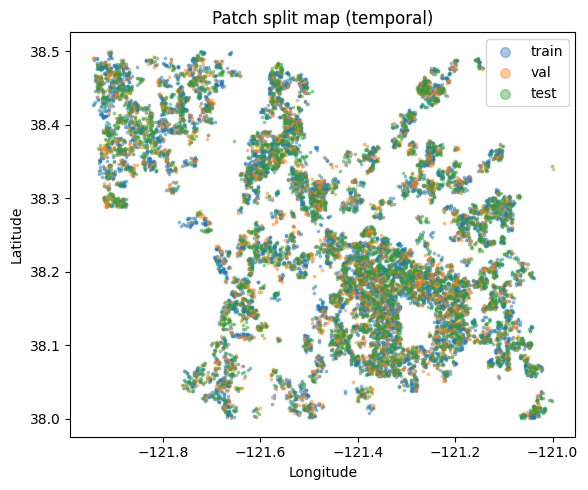

In [22]:
manifest_lookup_full = manifest_details_df.set_index("file").to_dict("index")

if SPLIT_STRATEGY == "temporal":
    def _split_of(fname):
        y = manifest_lookup_full.get(fname, {}).get("year")
        if y in SPLIT_TRAIN_YEARS: return "train"
        if y == SPLIT_VAL_YEAR:    return "val"
        if y == SPLIT_TEST_YEAR:   return "test"
        return None
    split_assignment = {f: _split_of(f) for f in valid_files}

else:  # spatial_block
    def _block_id(lon, lat, size=GEO_BLOCK_SIZE_DEG):
        return (math.floor(lon / size), math.floor(lat / size))
    blocks = {}
    for f in valid_files:
        meta = manifest_lookup_full.get(f, {})
        lon, lat = meta.get("longitude"), meta.get("latitude")
        if lon is None or lat is None:
            continue
        blocks.setdefault(_block_id(lon, lat), []).append(f)
    block_ids = sorted(blocks.keys())
    rng_blocks = np.random.default_rng(SEED)
    rng_blocks.shuffle(block_ids)
    n_blocks = len(block_ids)
    n_train_blk = int(round(SPATIAL_SPLIT_FRACTIONS["train"] * n_blocks))
    n_val_blk   = int(round(SPATIAL_SPLIT_FRACTIONS["val"]   * n_blocks))
    train_blocks = set(block_ids[:n_train_blk])
    val_blocks   = set(block_ids[n_train_blk:n_train_blk + n_val_blk])
    test_blocks  = set(block_ids[n_train_blk + n_val_blk:])
    split_assignment = {}
    for bid, files_in_block in blocks.items():
        s = "train" if bid in train_blocks else ("val" if bid in val_blocks else "test")
        for f in files_in_block:
            split_assignment[f] = s
    print(f"Spatial blocks: {n_blocks} total (~{GEO_BLOCK_SIZE_DEG} deg each) "
          f"-> {len(train_blocks)} train / {len(val_blocks)} val / {len(test_blocks)} test blocks")

train_names_all = sorted(f for f, s in split_assignment.items() if s == "train")
val_names_all   = sorted(f for f, s in split_assignment.items() if s == "val")
test_names_all  = sorted(f for f, s in split_assignment.items() if s == "test")

assert (len(train_names_all) + len(val_names_all) + len(test_names_all) ==
        sum(1 for s in split_assignment.values() if s is not None)), \
    "Some patches were not assigned a split."

def _split_rows(names):
    out = []
    for f in names:
        meta = manifest_lookup_full.get(f, {})
        out.append({"file": f, "year": meta.get("year"), "longitude": meta.get("longitude"),
                    "latitude": meta.get("latitude"), "crop_label": meta.get("crop_label")})
    return pd.DataFrame(out)

train_split_df = _split_rows(train_names_all)
val_split_df   = _split_rows(val_names_all)
test_split_df  = _split_rows(test_names_all)
train_split_df.to_csv(TRAIN_CSV, index=False)
val_split_df.to_csv(VAL_CSV, index=False)
test_split_df.to_csv(TEST_CSV, index=False)

# no overlap between train / validation / test filenames
s_train, s_val, s_test = set(train_names_all), set(val_names_all), set(test_names_all)
assert not (s_train & s_val), "train/val overlap!"
assert not (s_train & s_test), "train/test overlap!"
assert not (s_val & s_test), "val/test overlap!"

run_manifest.update({
    "split_strategy_used": SPLIT_STRATEGY,
    "num_train_files": len(train_names_all), "num_val_files": len(val_names_all),
    "num_test_files": len(test_names_all),
})
save_manifest()

print(f"Split strategy: {SPLIT_STRATEGY}")
print(f"Train: {len(train_names_all)} | Val: {len(val_names_all)} | Test: {len(test_names_all)}")
print("No overlap between train/val/test filenames: confirmed.")
print("Saved:", TRAIN_CSV, "|", VAL_CSV, "|", TEST_CSV)

# diagnostic map of the split (helps visually confirm no leakage across nearby patches)
try:
    plt.figure(figsize=(6, 5))
    for name, df_, color in [("train", train_split_df, "tab:blue"),
                             ("val", val_split_df, "tab:orange"),
                             ("test", test_split_df, "tab:green")]:
        plt.scatter(df_["longitude"], df_["latitude"], s=3, alpha=0.4, label=name, color=color)
    plt.xlabel("Longitude"); plt.ylabel("Latitude"); plt.legend(markerscale=4)
    plt.title(f"Patch split map ({SPLIT_STRATEGY})")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "figure_split_map.png", dpi=200, bbox_inches="tight")
    plt.show()
except Exception as e:
    print("Split map skipped:", e)


In [23]:
class SRPairsDataset(Dataset):
    def __init__(self, pair_dir, file_names, max_items=None):
        self.pair_dir = Path(pair_dir)
        self.files = list(file_names)[:max_items] if max_items else list(file_names)
    def __len__(self):
        return len(self.files)
    def __getitem__(self, idx):
        lr, hr = read_pair(self.pair_dir / self.files[idx])
        if hr.max() > 2.0 or lr.max() > 2.0:      # safety: rescale if stored as raw DN
            hr = hr / 10000.0; lr = lr / 10000.0
        hr = np.clip(hr, 0, 1).astype(np.float32)
        lr = np.clip(lr, 0, 1).astype(np.float32)
        return (torch.from_numpy(np.transpose(lr, (2, 0, 1))),
                torch.from_numpy(np.transpose(hr, (2, 0, 1))))

MAX_TRAIN = None
MAX_VAL   = None
BATCH_SIZE = 16 if str(device) == "cuda" else 4

train_ds = SRPairsDataset(PAIRS_SOURCE, train_names_all, max_items=MAX_TRAIN)
val_ds   = SRPairsDataset(PAIRS_SOURCE, val_names_all,   max_items=MAX_VAL)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
# The test set is deliberately NOT wrapped in a batched DataLoader: every test patch is
# scored individually in Step 13 so the reported metrics are batch-size independent.
run_manifest["num_train_patches_used"] = len(train_ds)
run_manifest["num_val_patches_used"] = len(val_ds)
run_manifest["num_test_patches_used"] = len(test_names_all)
run_manifest["batch_size"] = BATCH_SIZE
save_manifest()

lr_b, hr_b = next(iter(train_loader))
print("Train:", len(train_ds), "| Val:", len(val_ds), "| Test:", len(test_names_all))
print("LR batch:", tuple(lr_b.shape), "| HR batch:", tuple(hr_b.shape))
print("Tensors are channels-first (N, C, H, W) - describe them that way in Methods.")

Train: 9000 | Val: 3000 | Test: 3000
LR batch: (16, 4, 32, 32) | HR batch: (16, 4, 128, 128)
Tensors are channels-first (N, C, H, W) - describe them that way in Methods.


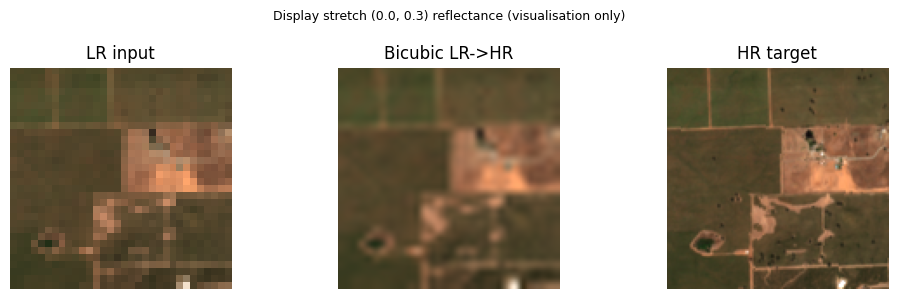

In [24]:
# data sanity figure (LR vs bicubic-upsampled vs HR).
def chw_to_hwc(x):
    if x.ndim == 4:
        x = x[0]
    return np.transpose(x.detach().cpu().numpy(), (1, 2, 0))

def to_display_rgb(img_hwc, stretch=DISPLAY_STRETCH):
    """Fixed reflectance stretch for display ONLY. Band order is B4,B3,B2,B8, so the RGB
    panel is channels [0,1,2]. This never touches the arrays used for metrics."""
    if img_hwc.shape[-1] < 3:
        img_hwc = np.repeat(img_hwc[..., :1], 3, axis=-1)
    rgb = img_hwc[..., :3]
    lo, hi = stretch
    return np.clip((rgb - lo) / (hi - lo), 0, 1)

rgb_like = to_display_rgb   # backwards-compatible alias

lr0, hr0 = lr_b[0:1], hr_b[0:1]
lr0_up = F.interpolate(lr0, size=hr0.shape[-2:], mode="bicubic", align_corners=False)
plt.figure(figsize=(10, 3))
for i, (title, ten) in enumerate([("LR input", lr0), ("Bicubic LR->HR", lr0_up), ("HR target", hr0)], 1):
    plt.subplot(1, 3, i); plt.imshow(to_display_rgb(chw_to_hwc(ten))); plt.title(title); plt.axis("off")
plt.suptitle(f"Display stretch {DISPLAY_STRETCH} reflectance (visualisation only)", fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "figure_data_sanity_patch.png", dpi=200, bbox_inches="tight"); plt.show()

# Step 12: SR model, metrics, and training

Residual CNN that bicubic-upsamples the LR input by the detected scale, then learns a residual correction. Reconstruction metrics: PSNR, MAE, MSE, SSIM. Vegetation-signal metric: NDVI RMSE.


In [25]:
class ResidualBlock(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.conv1 = nn.Conv2d(c, c, 3, padding=1)
        self.conv2 = nn.Conv2d(c, c, 3, padding=1)
    def forward(self, x):
        return F.relu(x + self.conv2(F.relu(self.conv1(x))))

class ResidualSRNet(nn.Module):
    def __init__(self, in_channels, hidden_channels=64, num_blocks=6, scale=2):
        super().__init__()
        self.scale = scale
        self.entry = nn.Conv2d(in_channels, hidden_channels, 5, padding=2)
        self.blocks = nn.Sequential(*[ResidualBlock(hidden_channels) for _ in range(num_blocks)])
        self.exit = nn.Conv2d(hidden_channels, in_channels, 3, padding=1)
    def forward(self, x):
        x_up = F.interpolate(x, scale_factor=self.scale, mode="bicubic", align_corners=False)
        h = F.relu(self.entry(x_up))
        h = self.blocks(h)
        return torch.clamp(x_up + self.exit(h), 0, 1)

model = ResidualSRNet(in_channels=IN_CHANNELS, hidden_channels=64, num_blocks=6, scale=DETECTED_SCALE).to(device)
print(model)

ResidualSRNet(
  (entry): Conv2d(4, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (blocks): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (1): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (2): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (3): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (4): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2

In [26]:
def mae_t(a, b):  return F.l1_loss(a, b).item()
def mse_t(a, b):  return F.mse_loss(a, b).item()
def psnr_t(a, b):
    m = F.mse_loss(a, b).item()
    return float("inf") if m == 0 else -10 * math.log10(m)
def grad_loss(p, t):
    return (F.l1_loss(p[:, :, :, 1:] - p[:, :, :, :-1], t[:, :, :, 1:] - t[:, :, :, :-1]) +
            F.l1_loss(p[:, :, 1:, :] - p[:, :, :-1, :], t[:, :, 1:, :] - t[:, :, :-1, :]))
def sr_loss(p, t):
    return F.l1_loss(p, t) + 0.05 * grad_loss(p, t)

def compute_ndvi_tensor(x, red_idx=RED_IDX, nir_idx=NIR_IDX, eps=1e-6):
    if x.shape[1] <= max(red_idx, nir_idx):
        return None
    red = x[:, red_idx:red_idx+1]; nir = x[:, nir_idx:nir_idx+1]
    return torch.clamp((nir - red) / (nir + red + eps), -1, 1)
def ndvi_rmse_t(a, b):
    na, nb = compute_ndvi_tensor(a), compute_ndvi_tensor(b)
    if na is None or nb is None:
        return np.nan
    return torch.sqrt(F.mse_loss(na, nb)).item()

def ssim_metric(a, b):
    if not SKIMAGE_AVAILABLE:
        return np.nan
    A = a.detach().cpu().numpy(); B = b.detach().cpu().numpy()
    vals = []
    for i in range(A.shape[0]):
        ah = np.transpose(A[i], (1, 2, 0)); bh = np.transpose(B[i], (1, 2, 0))
        vals.append(ssim(ah, bh, data_range=1.0, channel_axis=-1))
    return float(np.mean(vals))

# quick correctness self-check of the NDVI band order
_t = torch.zeros(1, IN_CHANNELS, 4, 4); _t[:, RED_IDX] = 0.1; _t[:, NIR_IDX] = 0.5
_nd = compute_ndvi_tensor(_t)
print("NDVI band-order self-check:", round(float(_nd.mean()), 4), "(expected ~0.6667 for veg)")
print("Metric helpers ready.")

NDVI band-order self-check: 0.6667 (expected ~0.6667 for veg)
Metric helpers ready.


In [27]:
# NOTE: this is a coarse, BATCH-AVERAGED sanity check on the VALIDATION set only
def evaluate_bicubic(loader):
    rows = []
    for lr, hr in loader:
        lr = lr.to(device); hr = hr.to(device)
        bic = torch.clamp(F.interpolate(lr, size=hr.shape[-2:], mode="bicubic", align_corners=False), 0, 1)
        rows.append({"mae": mae_t(bic, hr), "mse": mse_t(bic, hr), "psnr": psnr_t(bic, hr),
                     "ndvi_rmse": ndvi_rmse_t(bic, hr), "ssim": ssim_metric(bic, hr)})
    return pd.DataFrame(rows).mean(numeric_only=True).to_dict()

bicubic_metrics = evaluate_bicubic(val_loader)
print("Bicubic baseline (validation, batch-mean, diagnostic only):",
      {k: round(v, 5) for k, v in bicubic_metrics.items()})


Bicubic baseline (validation, batch-mean, diagnostic only): {'mae': 0.00868, 'mse': 0.00024, 'psnr': 36.3401, 'ndvi_rmse': 0.06237, 'ssim': 0.90816}


In [28]:
LEARNING_RATE = 5e-4
NUM_EPOCHS    = 40
PATIENCE      = 8

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
best_val_loss = float("inf"); best_epoch = -1; epochs_no_improve = 0
history = []
best_model_path = CHECKPOINT_DIR / "best_sr_model.pt"

# NOTE: also a batch-averaged, VALIDATION-set-only diagnostic, used only to pick the
# best checkpoint (early stopping). The final reported TEST metrics are computed
# per-patch in Step 13, not from this function.
def evaluate_model():
    model.eval(); rows = []
    with torch.no_grad():
        for lr, hr in val_loader:
            lr = lr.to(device); hr = hr.to(device); pred = model(lr)
            rows.append({"loss": sr_loss(pred, hr).item(), "mae": mae_t(pred, hr), "mse": mse_t(pred, hr),
                         "psnr": psnr_t(pred, hr), "ndvi_rmse": ndvi_rmse_t(pred, hr),
                         "ssim": ssim_metric(pred, hr)})
    return pd.DataFrame(rows).mean(numeric_only=True).to_dict()

for epoch in range(1, NUM_EPOCHS + 1):
    model.train(); losses = []
    for lr, hr in train_loader:
        lr = lr.to(device); hr = hr.to(device)
        optimizer.zero_grad()
        loss = sr_loss(model(lr), hr)
        loss.backward(); optimizer.step()
        losses.append(loss.item())
    train_loss = float(np.mean(losses))
    vm = evaluate_model()
    history.append({"epoch": epoch, "train_loss": train_loss, **{f"val_{k}": v for k, v in vm.items()}})
    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | train_loss={train_loss:.5f} | "
          f"val_loss={vm['loss']:.5f} | val_psnr={vm['psnr']:.3f}")
    if vm["loss"] < best_val_loss:
        best_val_loss = vm["loss"]; best_epoch = epoch; epochs_no_improve = 0
        torch.save({"model_state_dict": model.state_dict(), "scale": DETECTED_SCALE,
                    "in_channels": IN_CHANNELS, "epoch": epoch, "val_metrics": vm}, best_model_path)
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print("Early stopping."); break

history_df = pd.DataFrame(history)
history_df.to_csv(RESULTS_DIR / "sr_training_history.csv", index=False)
display(history_df.tail())
print("Best epoch:", best_epoch, "| saved:", best_model_path)

Epoch 01/40 | train_loss=0.00914 | val_loss=0.00863 | val_psnr=36.953
Epoch 02/40 | train_loss=0.00815 | val_loss=0.00845 | val_psnr=37.113
Epoch 03/40 | train_loss=0.00795 | val_loss=0.00827 | val_psnr=37.277
Epoch 04/40 | train_loss=0.00781 | val_loss=0.00813 | val_psnr=37.394
Epoch 05/40 | train_loss=0.00770 | val_loss=0.00811 | val_psnr=37.421
Epoch 06/40 | train_loss=0.00763 | val_loss=0.00798 | val_psnr=37.550
Epoch 07/40 | train_loss=0.00757 | val_loss=0.00801 | val_psnr=37.520
Epoch 08/40 | train_loss=0.00751 | val_loss=0.00792 | val_psnr=37.596
Epoch 09/40 | train_loss=0.00747 | val_loss=0.00788 | val_psnr=37.652
Epoch 10/40 | train_loss=0.00742 | val_loss=0.00786 | val_psnr=37.652
Epoch 11/40 | train_loss=0.00739 | val_loss=0.00779 | val_psnr=37.739
Epoch 12/40 | train_loss=0.00736 | val_loss=0.00783 | val_psnr=37.697
Epoch 13/40 | train_loss=0.00732 | val_loss=0.00776 | val_psnr=37.796
Epoch 14/40 | train_loss=0.00730 | val_loss=0.00772 | val_psnr=37.824
Epoch 15/40 | train_

,epoch,train_loss,val_loss,val_mae,val_mse,val_psnr,val_ndvi_rmse,val_ssim
35,36,0.006984,0.007485,0.006854,0.000160,38.063589,0.046586,0.938674
36,37,0.006984,0.007464,0.006835,0.000159,38.096401,0.046962,0.938904
37,38,0.006978,0.007465,0.006836,0.000159,38.101019,0.046634,0.938972
38,39,0.006969,0.007433,0.006805,0.000158,38.129812,0.046625,0.939503
39,40,0.006965,0.007447,0.006819,0.000159,38.106083,0.048171,0.939281


Best epoch: 39 | saved: /content/checkpoints/best_sr_model.pt


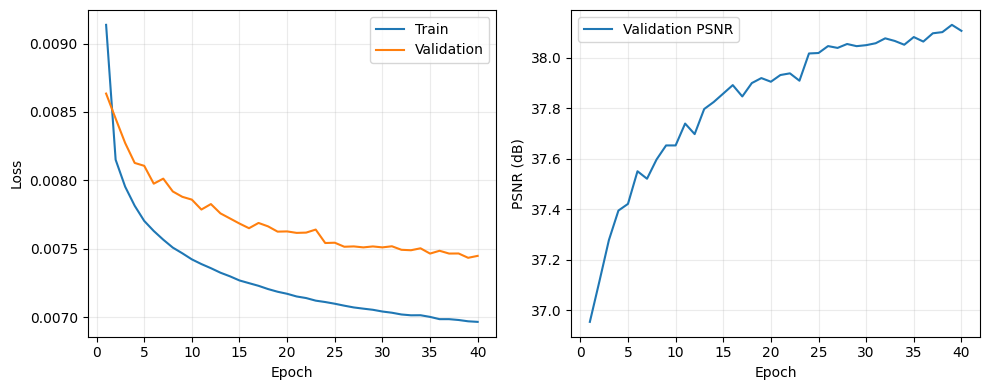

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(history_df["epoch"], history_df["train_loss"], label="Train")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="Validation")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.25)
axes[1].plot(history_df["epoch"], history_df["val_psnr"], label="Validation PSNR")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("PSNR (dB)"); axes[1].legend(); axes[1].grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig(FIG_DIR / "figure_sr_training_curves.png", dpi=250, bbox_inches="tight"); plt.show()

# Step 13: Final test-set evaluation

Outputs: `test_patch_metrics.csv` (one row per test patch, including `dominant_crop_fraction`), `sr_bicubic_vs_model_metrics.csv` (mean/SD/median/95% CI per metric per method plus the paired model-minus-bicubic difference), and `sr_metrics_by_crop.csv`.

The headline numbers are **aggregate agricultural-patch** results. The crop breakdown is by **dominant crop label** -- the 30% threshold applies to combined target-crop cover, so those are not pure single-crop patches -- and it reports a stricter subset filtered on the dominant crop's own coverage.


In [30]:
# reload best checkpoint (weights_only=False so the metadata dict loads on new PyTorch)
checkpoint = torch.load(best_model_path, map_location="cpu", weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device); model.eval()
print("Reloaded best model from epoch", checkpoint.get("epoch"))

manifest_lookup = manifest_details_df.set_index("file").to_dict("index")

def eval_one_test_patch(fname, keep_tensors=False):
    """Score exactly ONE patch: bicubic vs model, both against its own HR target.
    No batching and no averaging here -- aggregation happens afterwards over the per-patch
    rows, which is what makes the reported numbers batch-size independent."""
    lr, hr = read_pair(PAIRS_SOURCE / fname)
    if hr.max() > 2.0 or lr.max() > 2.0:
        hr = hr / 10000.0; lr = lr / 10000.0
    hr = np.clip(hr, 0, 1).astype(np.float32); lr = np.clip(lr, 0, 1).astype(np.float32)
    lr_t = torch.from_numpy(np.transpose(lr, (2, 0, 1))).unsqueeze(0).to(device)
    hr_t = torch.from_numpy(np.transpose(hr, (2, 0, 1))).unsqueeze(0).to(device)
    with torch.no_grad():
        bic = torch.clamp(F.interpolate(lr_t, size=hr_t.shape[-2:], mode="bicubic",
                                        align_corners=False), 0, 1)
        pred = model(lr_t)
    meta = manifest_lookup.get(fname, {})
    # crop_label is the DOMINANT target crop. crop_fraction is the COMBINED cover of all
    # target crops (what MIN_CROP_FRACTION gates on); dominant_crop_fraction is how much of
    # the patch that one labelled crop actually covers. Both are carried into
    # test_patch_metrics.csv so crop-labelled results can be filtered and defended.
    row = {
        "file": fname, "year": meta.get("year"), "crop_label": meta.get("crop_label"),
        "crop_fraction": meta.get("crop_fraction"),
        "dominant_crop_fraction": meta.get("dominant_crop_fraction"),
        "bicubic_mae": mae_t(bic, hr_t), "model_mae": mae_t(pred, hr_t),
        "bicubic_mse": mse_t(bic, hr_t), "model_mse": mse_t(pred, hr_t),
        "bicubic_psnr": psnr_t(bic, hr_t), "model_psnr": psnr_t(pred, hr_t),
        "bicubic_ssim": ssim_metric(bic, hr_t), "model_ssim": ssim_metric(pred, hr_t),
        "bicubic_ndvi_rmse": ndvi_rmse_t(bic, hr_t), "model_ndvi_rmse": ndvi_rmse_t(pred, hr_t),
    }
    tensors = (lr_t.cpu(), bic.cpu(), pred.cpu(), hr_t.cpu()) if keep_tensors else None
    return row, tensors

# --- pass 1: score every held-out test patch ---
test_patch_rows = []
for fname in test_names_all:
    row, _ = eval_one_test_patch(fname)
    test_patch_rows.append(row)

test_patch_metrics_df = pd.DataFrame(test_patch_rows)
test_patch_metrics_df.to_csv(RESULTS_DIR / "test_patch_metrics.csv", index=False)
print("Saved per-patch TEST metrics:", RESULTS_DIR / "test_patch_metrics.csv",
      "| rows:", len(test_patch_metrics_df))
_dom = pd.to_numeric(test_patch_metrics_df.get("dominant_crop_fraction"), errors="coerce")
if _dom is not None and _dom.notna().any():
    print(f"dominant_crop_fraction recorded for {int(_dom.notna().sum())}/"
          f"{len(test_patch_metrics_df)} test patches | median {_dom.median():.3f} | "
          f"{int((_dom >= MIN_DOMINANT_CROP_FRACTION).sum())} at or above the "
          f"{MIN_DOMINANT_CROP_FRACTION:.0%} dominant-crop floor")
else:
    print("WARNING: dominant_crop_fraction is missing for every test patch. Crop-labelled SR "
          "results cannot be filtered by dominant-crop cover until the manifest is regenerated.")

def select_example_files(df, rule=EXAMPLE_SELECTION_RULE, k=N_FIGURE_EXAMPLES):
    d = df.dropna(subset=["model_psnr"]).sort_values("model_psnr").reset_index(drop=True)
    if len(d) == 0:
        return []
    if rule == "median_psnr":
        mid = len(d) // 2
        start = max(0, min(mid - k // 2, len(d) - k))
        chosen = d.iloc[start:start + k]
    elif rule == "quartiles":
        qs = [0.25, 0.50, 0.75][:k]
        chosen = d.iloc[[int(q * (len(d) - 1)) for q in qs]]
    elif rule == "seeded_random":
        chosen = d.sample(min(k, len(d)), random_state=SEED)
    else:
        raise ValueError(f"Unknown EXAMPLE_SELECTION_RULE: {rule}")
    return chosen

example_rows = select_example_files(test_patch_metrics_df)
example_files = list(example_rows["file"])
example_rows.assign(selection_rule=EXAMPLE_SELECTION_RULE).to_csv(
    RESULTS_DIR / "figure_example_patches.csv", index=False)

test_examples = []
for fname in example_files:
    _, tensors = eval_one_test_patch(fname, keep_tensors=True)
    lr_t, bic_t, pred_t, hr_t = tensors
    ex_psnr = float(test_patch_metrics_df.loc[
        test_patch_metrics_df["file"] == fname, "model_psnr"].iloc[0])
    test_examples.append({"file": fname, "model_psnr": ex_psnr,
                          "lr": lr_t[0], "bicubic": bic_t[0], "model": pred_t[0], "hr": hr_t[0]})

run_manifest["figure_example_selection_rule"] = EXAMPLE_SELECTION_RULE
run_manifest["figure_example_files"] = example_files
save_manifest()

print(f"\nQualitative examples selected by rule '{EXAMPLE_SELECTION_RULE}' "
      f"(recorded in results/figure_example_patches.csv):")
for ex in test_examples:
    print(f"   {ex['file']}  model PSNR {ex['model_psnr']:.2f} dB")
print("State this selection rule in the figure caption.")
display(test_patch_metrics_df.head())

Reloaded best model from epoch 39
Saved per-patch TEST metrics: /content/results/test_patch_metrics.csv | rows: 3000
dominant_crop_fraction recorded for 3000/3000 test patches | median 0.511 | 2637 at or above the 30% dominant-crop floor

Qualitative examples selected by rule 'median_psnr' (recorded in results/figure_example_patches.csv):
   S2_2022_m121.36885_38.22869.npz  model PSNR 38.60 dB
   S2_2022_m121.55222_38.39907.npz  model PSNR 38.60 dB
   S2_2022_m121.45160_38.08071.npz  model PSNR 38.61 dB
State this selection rule in the figure caption.


,file,year,crop_label,crop_fraction,dominant_crop_fraction,bicubic_mae,model_mae,bicubic_mse,model_mse,bicubic_psnr,model_psnr,bicubic_ssim,model_ssim,bicubic_ndvi_rmse,model_ndvi_rmse
0,S2_2022_m121.00092_38.02455.npz,2022,GRAPES,0.368367,0.362636,0.008665,0.006060,0.000204,0.000117,36.911095,39.323784,0.900671,0.944733,0.073731,0.052711
1,S2_2022_m121.00116_38.34327.npz,2022,ALFALFA,0.415551,0.393595,0.008318,0.006959,0.000199,0.000155,37.011790,38.095491,0.905580,0.931701,0.065536,0.053903
2,S2_2022_m121.00630_38.02565.npz,2022,GRAPES,0.515653,0.511531,0.007362,0.005078,0.000158,0.000080,38.025887,40.955209,0.922133,0.962450,0.059676,0.040190
3,S2_2022_m121.01532_38.01046.npz,2022,GRAPES,0.448150,0.431371,0.007751,0.005826,0.000149,0.000090,38.282613,40.469220,0.915446,0.949988,0.061106,0.041571
4,S2_2022_m121.01624_38.01414.npz,2022,GRAPES,0.379501,0.371430,0.007706,0.005999,0.000164,0.000104,37.864045,39.848128,0.921469,0.949131,0.056192,0.039156


In [31]:
def mean_ci95(x):
    """Mean, std, median, and a normal-approximation 95% CI, ignoring non-finite values."""
    x = np.asarray(pd.to_numeric(x, errors="coerce"), dtype=float)
    x = x[np.isfinite(x)]
    n = len(x)
    if n == 0:
        return dict(n=0, mean=np.nan, std=np.nan, median=np.nan, ci95_low=np.nan, ci95_high=np.nan)
    m = float(x.mean()); s = float(x.std(ddof=1)) if n > 1 else 0.0
    se = s / math.sqrt(n) if n > 0 else np.nan
    return dict(n=n, mean=m, std=s, median=float(np.median(x)),
               ci95_low=m - 1.96 * se, ci95_high=m + 1.96 * se)

METRIC_NAMES = ["mae", "mse", "psnr", "ssim", "ndvi_rmse"]
LOWER_IS_BETTER = {"mae", "mse", "ndvi_rmse"}

summary_rows = []
for metric in METRIC_NAMES:
    for method in ["bicubic", "model"]:
        stats = mean_ci95(test_patch_metrics_df[f"{method}_{metric}"])
        stats.update({"metric": metric, "method": method})
        summary_rows.append(stats)
    # paired comparison: bicubic and model are scored on the SAME patches, so compare the
    # per-patch differences directly rather than two independent-sample summaries
    diff = test_patch_metrics_df[f"model_{metric}"] - test_patch_metrics_df[f"bicubic_{metric}"]
    dstats = mean_ci95(diff)
    dstats.update({"metric": metric, "method": "model_minus_bicubic_paired"})
    if SCIPY_AVAILABLE:
        finite_idx = diff[np.isfinite(diff)].index
        if len(finite_idx) > 1:
            _, pval = scipy_stats.ttest_rel(
                test_patch_metrics_df.loc[finite_idx, f"model_{metric}"],
                test_patch_metrics_df.loc[finite_idx, f"bicubic_{metric}"])
            dstats["paired_p_value"] = float(pval)
    summary_rows.append(dstats)

test_metrics_summary_df = pd.DataFrame(summary_rows)
front_cols = ["metric", "method", "n", "mean", "std", "median", "ci95_low", "ci95_high"]
other_cols = [c for c in test_metrics_summary_df.columns if c not in front_cols]
test_metrics_summary_df = test_metrics_summary_df[front_cols + other_cols]
test_metrics_summary_df.to_csv(RESULTS_DIR / "sr_bicubic_vs_model_metrics.csv", index=False)
display(test_metrics_summary_df.round(5))

def _mean_of(metric, method):
    r = test_metrics_summary_df[(test_metrics_summary_df["metric"] == metric) &
                                (test_metrics_summary_df["method"] == method)]
    return float(r["mean"].iloc[0]) if len(r) else float("nan")

psnr_b, psnr_m = _mean_of("psnr", "bicubic"), _mean_of("psnr", "model")
ndvi_b, ndvi_m = _mean_of("ndvi_rmse", "bicubic"), _mean_of("ndvi_rmse", "model")
print(f"\nTest-set mean PSNR - bicubic: {psnr_b:.3f} dB | model: {psnr_m:.3f} dB "
      f"(n={len(test_patch_metrics_df)} patches)")
print(f"Test-set mean NDVI RMSE - bicubic: {ndvi_b:.4f} | model: {ndvi_m:.4f}")
if psnr_m <= psnr_b:
    print("GUARDRAIL: model did NOT beat bicubic on mean test PSNR. "
          "Report it as a baseline, do not claim SR improvement.")


,metric,method,n,mean,std,median,ci95_low,ci95_high,paired_p_value
0,mae,bicubic,3000,0.00873,0.00210,0.00849,0.00865,0.00880,NaN
1,mae,model,3000,0.00676,0.00188,0.00645,0.00669,0.00683,NaN
2,mae,model_minus_bicubic_paired,3000,-0.00197,0.00069,-0.00191,-0.00199,-0.00194,0.0
3,mse,bicubic,3000,0.00024,0.00011,0.00022,0.00024,0.00025,NaN
4,mse,model,3000,0.00016,0.00009,0.00014,0.00016,0.00016,NaN
5,mse,model_minus_bicubic_paired,3000,-0.00008,0.00004,-0.00008,-0.00008,-0.00008,0.0
6,psnr,bicubic,3000,36.59486,1.95098,36.52024,36.52505,36.66468,NaN
7,psnr,model,3000,38.55832,2.22739,38.60257,38.47861,38.63803,NaN
8,psnr,model_minus_bicubic_paired,3000,1.96345,0.84121,1.83721,1.93335,1.99356,0.0
9,ssim,bicubic,3000,0.90719,0.02705,0.91027,0.90622,0.90816,NaN



Test-set mean PSNR - bicubic: 36.595 dB | model: 38.558 dB (n=3000 patches)
Test-set mean NDVI RMSE - bicubic: 0.0668 | model: 0.0490


In [32]:
# Crop-broken-out SR results.
#
# crop_label is the DOMINANT target crop in a patch. MIN_CROP_FRACTION (30%) constrains the
# COMBINED cover of all target crops, so a patch labelled "GRAPES" is not guaranteed to be
# 30% grapes and is certainly not a pure grape patch. Every row below is therefore reported
# as dominant-crop-LABELLED, and each row is repeated under a stricter filter that keeps only
# patches whose own dominant crop covers at least MIN_DOMINANT_CROP_FRACTION of the patch.
#
# Target crops with zero test patches are listed explicitly with NaN metrics rather than
# omitted, so absence cannot be mistaken for adequate performance.

DOMINANT_LABEL_CAVEAT = (
    "rows are dominant-crop-LABELLED patches, not pure single-crop patches: crop_label is the "
    f"dominant target crop, while the {MIN_CROP_FRACTION:.0%} threshold applies to the combined "
    "cover of all target crops")
STRICT_PREFIX = f"domfrac_ge_{int(round(MIN_DOMINANT_CROP_FRACTION * 100))}pct_"

tpm = test_patch_metrics_df.copy()
if "dominant_crop_fraction" not in tpm.columns:
    tpm["dominant_crop_fraction"] = np.nan
tpm["dominant_crop_fraction"] = pd.to_numeric(tpm["dominant_crop_fraction"], errors="coerce")

def _metric_block(sub, prefix=""):
    n = int(len(sub))
    def _m(col):
        return float(sub[col].mean()) if n else np.nan
    return {f"{prefix}test_patches": n,
            f"{prefix}bicubic_psnr": _m("bicubic_psnr"), f"{prefix}model_psnr": _m("model_psnr"),
            f"{prefix}bicubic_ndvi_rmse": _m("bicubic_ndvi_rmse"),
            f"{prefix}model_ndvi_rmse": _m("model_ndvi_rmse")}

empty_like = tpm.iloc[0:0]
crop_rows = []
for crop, sub in tpm.groupby("crop_label", dropna=False):
    crop_name = crop if pd.notna(crop) else "unlabeled"
    strict = sub[sub["dominant_crop_fraction"] >= MIN_DOMINANT_CROP_FRACTION]
    row = {"crop": crop_name, "status": "dominant_crop_labeled"}
    row.update(_metric_block(sub))
    row["median_dominant_crop_fraction"] = (float(sub["dominant_crop_fraction"].median())
                                            if sub["dominant_crop_fraction"].notna().any() else np.nan)
    row["min_dominant_crop_fraction"] = (float(sub["dominant_crop_fraction"].min())
                                         if sub["dominant_crop_fraction"].notna().any() else np.nan)
    row.update(_metric_block(strict, prefix=STRICT_PREFIX))
    crop_rows.append(row)

labelled_in_test = set(tpm["crop_label"].dropna().unique())
absent_in_test = [c for c in TARGET_CROPS if c not in labelled_in_test]
for crop_name in absent_in_test:
    declared = crop_name in SR_CLAIM_EXCLUDED_CROPS
    row = {"crop": crop_name,
           "status": ("absent_from_dataset_excluded_from_sr_claims" if declared
                      else "absent_from_test_set_UNDECLARED")}
    row.update(_metric_block(empty_like))
    row["median_dominant_crop_fraction"] = np.nan
    row["min_dominant_crop_fraction"] = np.nan
    row.update(_metric_block(empty_like, prefix=STRICT_PREFIX))
    crop_rows.append(row)

sr_metrics_by_crop_df = pd.DataFrame(crop_rows)
sr_metrics_by_crop_df = sr_metrics_by_crop_df.sort_values(
    ["test_patches", "crop"], ascending=[False, True]).reset_index(drop=True)
sr_metrics_by_crop_df.to_csv(RESULTS_DIR / "sr_metrics_by_crop.csv", index=False)
display(sr_metrics_by_crop_df.round(4))
print("CAVEAT for the crop table:", DOMINANT_LABEL_CAVEAT + ".")
print(f"Columns prefixed '{STRICT_PREFIX}' are the stricter subset whose dominant crop alone "
      f"covers >= {MIN_DOMINANT_CROP_FRACTION:.0%} of the patch. Use either the strict subset "
      "or the phrase 'dominant-crop-labelled' in the manuscript -- never 'crop-specific'.")

reported = sr_metrics_by_crop_df[sr_metrics_by_crop_df["status"] == "dominant_crop_labeled"]
thin_crops = reported.loc[reported["test_patches"] < MIN_TEST_CROP_COUNT, "crop"].tolist()
if thin_crops:
    print(f"\nNOTE: {thin_crops} have fewer than {MIN_TEST_CROP_COUNT} test patches. SR "
          "performance is not equally demonstrated for these -- report their per-crop numbers "
          "with that caveat and do not extend the aggregate claim to them.")

shrunk = reported[reported[f"{STRICT_PREFIX}test_patches"] < 0.9 * reported["test_patches"]]
for _, r in shrunk.iterrows():
    print(f"NOTE: {r['crop']} drops from {int(r['test_patches'])} to "
          f"{int(r[f'{STRICT_PREFIX}test_patches'])} patches under the "
          f"{MIN_DOMINANT_CROP_FRACTION:.0%} dominant-crop filter - the label is carried by "
          "mixed patches, so prefer the strict columns for any crop-level statement.")

if absent_in_test:
    print(f"\nABSENT from the test set entirely: {absent_in_test}. No SR metric exists for "
          "them and none can be reported.")
    for crop_name in absent_in_test:
        if crop_name in SR_CLAIM_EXCLUDED_CROPS:
            print(f"  - {crop_name}: declared excluded from SR claims "
                  f"({SR_CLAIM_EXCLUSION_REASON.get(crop_name, 'no reason recorded')}).")
        else:
            print(f"  - {crop_name}: NOT declared in SR_CLAIM_EXCLUDED_CROPS - Step 15 "
                  "readiness will fail until the manuscript excludes it explicitly.")

run_manifest["sr_crop_table_is_dominant_crop_labeled"] = True
run_manifest["sr_crop_table_caveat"] = DOMINANT_LABEL_CAVEAT
run_manifest["sr_crops_reported_in_test"] = sorted(labelled_in_test)
run_manifest["sr_crops_absent_from_test"] = absent_in_test
run_manifest["sr_thin_crops_in_test"] = thin_crops
save_manifest()


,crop,status,test_patches,bicubic_psnr,model_psnr,bicubic_ndvi_rmse,model_ndvi_rmse,median_dominant_crop_fraction,min_dominant_crop_fraction,domfrac_ge_30pct_test_patches,domfrac_ge_30pct_bicubic_psnr,domfrac_ge_30pct_model_psnr,domfrac_ge_30pct_bicubic_ndvi_rmse,domfrac_ge_30pct_model_ndvi_rmse
0,GRAPES,dominant_crop_labeled,1845,36.7122,38.6142,0.0660,0.0493,0.5997,0.1312,1702,36.8036,38.7185,0.0648,0.0484
1,ALFALFA,dominant_crop_labeled,782,35.8964,37.9295,0.0728,0.0517,0.4019,0.1501,623,36.0112,38.1167,0.0708,0.0499
2,ALMOND,dominant_crop_labeled,373,37.4789,39.6003,0.0584,0.0419,0.4591,0.1376,312,37.6325,39.8095,0.0575,0.0410
3,CITRUS,absent_from_dataset_excluded_from_sr_claims,0,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN


CAVEAT for the crop table: rows are dominant-crop-LABELLED patches, not pure single-crop patches: crop_label is the dominant target crop, while the 30% threshold applies to the combined cover of all target crops.
Columns prefixed 'domfrac_ge_30pct_' are the stricter subset whose dominant crop alone covers >= 30% of the patch. Use either the strict subset or the phrase 'dominant-crop-labelled' in the manuscript -- never 'crop-specific'.
NOTE: ALFALFA drops from 782 to 623 patches under the 30% dominant-crop filter - the label is carried by mixed patches, so prefer the strict columns for any crop-level statement.
NOTE: ALMOND drops from 373 to 312 patches under the 30% dominant-crop filter - the label is carried by mixed patches, so prefer the strict columns for any crop-level statement.

ABSENT from the test set entirely: ['CITRUS']. No SR metric exists for them and none can be reported.
  - CITRUS: declared excluded from SR claims (zero SR patches in the generated pair set (CDL citrus 

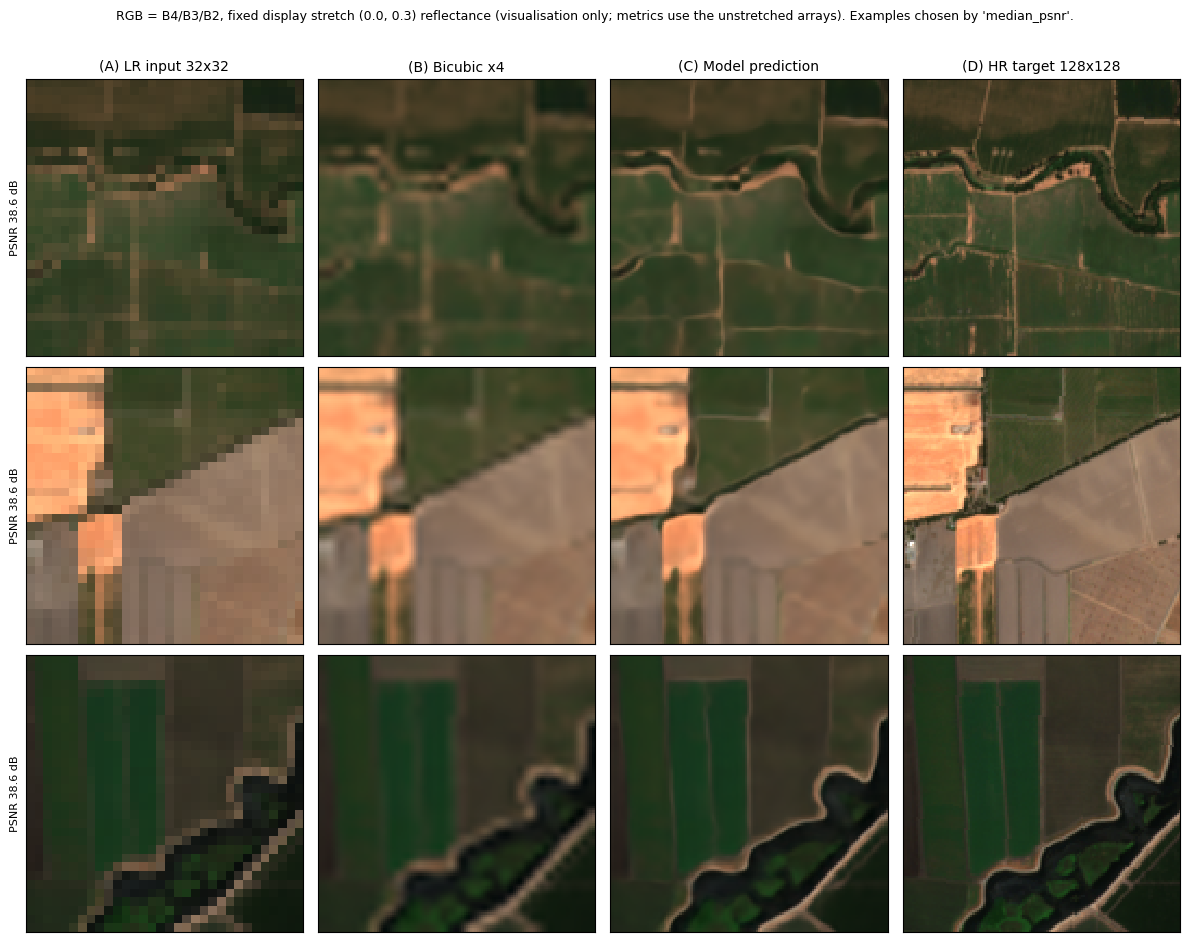

Saved: /content/figures/paper/figure_sr_visual_comparison.png


In [33]:
examples = test_examples
fig, axes = plt.subplots(len(examples), 4, figsize=(12, 3.1*len(examples)))
if len(examples) == 1:
    axes = np.array([axes])

panel_titles = ["(A) LR input 32x32", "(B) Bicubic x4", "(C) Model prediction", "(D) HR target 128x128"]
for r, ex in enumerate(examples):
    for c, key in enumerate(["lr", "bicubic", "model", "hr"]):
        axes[r, c].imshow(to_display_rgb(chw_to_hwc(ex[key])),
                          interpolation="nearest" if key == "lr" else "none")
        if r == 0:
            axes[r, c].set_title(panel_titles[c], fontsize=10)
        axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
    axes[r, 0].set_ylabel(f"PSNR {ex['model_psnr']:.1f} dB", fontsize=8)

fig.suptitle(
    f"RGB = B4/B3/B2, fixed display stretch {DISPLAY_STRETCH} reflectance (visualisation only; "
    f"metrics use the unstretched arrays). Examples chosen by '{EXAMPLE_SELECTION_RULE}'.",
    fontsize=9, y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / "figure_sr_visual_comparison.png", dpi=250, bbox_inches="tight"); plt.show()
print("Saved:", FIG_DIR / "figure_sr_visual_comparison.png")

   note: 2.5% of error pixels in S2_2022_m121.36885_38.22869.npz exceed the fixed display max 0.15 and are shown clipped.
   note: 5.2% of error pixels in S2_2022_m121.45160_38.08071.npz exceed the fixed display max 0.15 and are shown clipped.


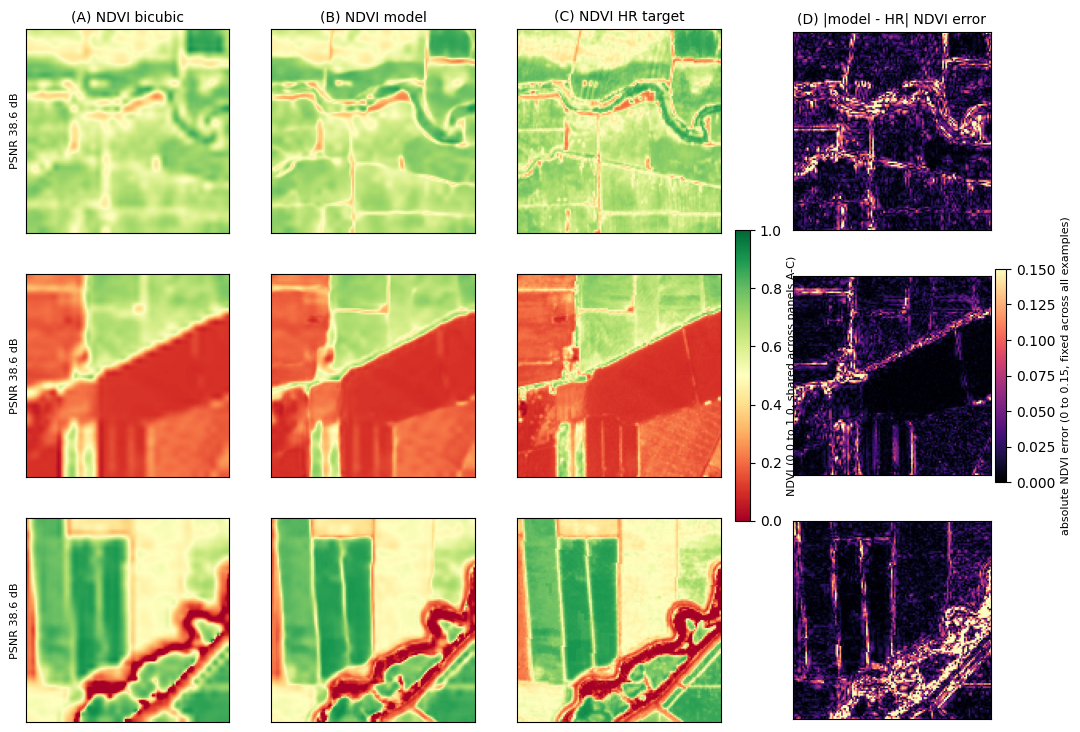

Saved: /content/figures/paper/figure_ndvi_impact.png
NDVI RMSE (TEST set) - bicubic: 0.0668 | model: 0.0490 | model better
NOTE: this NDVI RMSE is computed over the WHOLE patch, not only crop-masked pixels. State that in the manuscript.


In [34]:
def tensor_to_ndvi_2d(x_chw):
    nd = compute_ndvi_tensor(x_chw.unsqueeze(0))
    return None if nd is None else nd.squeeze().detach().cpu().numpy()

if IN_CHANNELS <= max(RED_IDX, NIR_IDX):
    print("Not enough channels to compute NDVI - skipping NDVI impact figure.")
else:
    fig, axes = plt.subplots(len(examples), 4, figsize=(13, 3.0*len(examples)))
    if len(examples) == 1:
        axes = np.array([axes])

    ndvi_im = err_im = None
    ptitles = ["(A) NDVI bicubic", "(B) NDVI model", "(C) NDVI HR target",
               "(D) |model - HR| NDVI error"]
    for r, ex in enumerate(examples):
        ndvi_bic = tensor_to_ndvi_2d(ex["bicubic"])
        ndvi_mod = tensor_to_ndvi_2d(ex["model"])
        ndvi_hr  = tensor_to_ndvi_2d(ex["hr"])
        ndvi_err = np.abs(ndvi_mod - ndvi_hr)
        for c, panel in enumerate([ndvi_bic, ndvi_mod, ndvi_hr]):
            ndvi_im = axes[r, c].imshow(panel, vmin=NDVI_VMIN, vmax=NDVI_VMAX, cmap="RdYlGn")
            if r == 0:
                axes[r, c].set_title(ptitles[c], fontsize=10)
            axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
        err_im = axes[r, 3].imshow(ndvi_err, vmin=0.0, vmax=NDVI_ERR_VMAX, cmap="magma")
        if r == 0:
            axes[r, 3].set_title(ptitles[3], fontsize=10)
        axes[r, 3].set_xticks([]); axes[r, 3].set_yticks([])
        axes[r, 0].set_ylabel(f"PSNR {ex['model_psnr']:.1f} dB", fontsize=8)
        frac_over = float((ndvi_err > NDVI_ERR_VMAX).mean())
        if frac_over > 0.01:
            print(f"   note: {frac_over*100:.1f}% of error pixels in {ex['file']} exceed the "
                  f"fixed display max {NDVI_ERR_VMAX} and are shown clipped.")

    fig.subplots_adjust(right=0.88)
    cb1 = fig.colorbar(ndvi_im, ax=axes[:, :3], fraction=0.02, pad=0.02)
    cb1.set_label(f"NDVI ({NDVI_VMIN} to {NDVI_VMAX}, shared across panels A-C)", fontsize=8)
    cb2 = fig.colorbar(err_im, ax=axes[:, 3], fraction=0.05, pad=0.02)
    cb2.set_label(f"absolute NDVI error (0 to {NDVI_ERR_VMAX}, fixed across all examples)", fontsize=8)

    fig.savefig(FIG_DIR / "figure_ndvi_impact.png", dpi=250, bbox_inches="tight"); plt.show()
    print("Saved:", FIG_DIR / "figure_ndvi_impact.png")
    print(f"NDVI RMSE (TEST set) - bicubic: {ndvi_b:.4f} | model: {ndvi_m:.4f} | "
          f"{'model better' if ndvi_m < ndvi_b else 'bicubic better'}")
    print("NOTE: this NDVI RMSE is computed over the WHOLE patch, not only crop-masked "
          "pixels. State that in the manuscript.")

# Step 14: Output checklist and pre-freeze readiness

Defines `evaluate_paper_readiness()` and runs it before the freeze, then writes the generated results snippets. The `paper_ready` flag itself is set in Step 15.


In [35]:
# Artifact / readiness check.
#
# paper_ready is NOT "the files exist". It means the frozen package is internally consistent:
# every required artifact exists AND was frozen, the reconciliation table and requirements
# file are present, the audit is clean, and every target crop with zero SR patches is
# explicitly recorded and explicitly excluded from the SR claims. The check therefore runs
# twice -- once here (pre-freeze, informational) and again at the end of Step 15 (post-freeze),
# which is the run that sets the flag.

REQUIRED_ARTIFACTS = {
    "run manifest":                RESULTS_DIR / "run_manifest.json",
    "precipitation labels":        RESULTS_DIR / "annual_precipitation_labels.csv",
    "baseline NDVI (all crops)":   RESULTS_DIR / "baseline_ndvi_all_crops.csv",
    "baseline NDVI summary":       RESULTS_DIR / "baseline_ndvi_summary.csv",
    "baseline NDVI annual means":  RESULTS_DIR / "baseline_ndvi_annual_means.csv",
    "baseline NDVI annual summary": RESULTS_DIR / "baseline_ndvi_annual_summary.csv",
    "data audit":                  RESULTS_DIR / "data_audit.csv",
    "manifest details":            RESULTS_DIR / "manifest_details.csv",
    "dataset summary":             RESULTS_DIR / "dataset_summary.csv",
    "patch counts by year/crop":   RESULTS_DIR / "patch_counts_by_year_crop.csv",
    "train split":                 TRAIN_CSV,
    "val split":                   VAL_CSV,
    "test split":                  TEST_CSV,
    "training history":            RESULTS_DIR / "sr_training_history.csv",
    "per-patch test metrics":      RESULTS_DIR / "test_patch_metrics.csv",
    "bicubic vs model summary":    RESULTS_DIR / "sr_bicubic_vs_model_metrics.csv",
    "per-crop SR metrics":         RESULTS_DIR / "sr_metrics_by_crop.csv",
    "figure example selection":    RESULTS_DIR / "figure_example_patches.csv",
    "model checkpoint":            CHECKPOINT_DIR / "best_sr_model.pt",
    "baseline NDVI figure":        FIG_DIR / "figure_baseline_ndvi_by_crop.png",
    "training curves figure":      FIG_DIR / "figure_sr_training_curves.png",
    "SR comparison figure":        FIG_DIR / "figure_sr_visual_comparison.png",
    "NDVI impact figure":          FIG_DIR / "figure_ndvi_impact.png",
}

SNIPPETS_MD        = PAPER_DIR / "generated_results_snippets.md"
RECONCILIATION_CSV = FROZEN_DIR / "manuscript_reconciliation.csv"
REQUIREMENTS_TXT   = PROJECT_ROOT / "requirements.txt"
ABSENCE_MARKER     = "ABSENT TARGET CROPS"


def evaluate_paper_readiness(stage="pre_freeze"):
    """Return (ready, problems).

    stage="pre_freeze"  - everything knowable before the artifacts are frozen.
    stage="post_freeze" - the same checks plus frozen-package consistency. Only this stage
                          may set paper_ready=True.
    """
    problems = []

    # ---- 1. required artifacts exist -------------------------------------------------
    for label, path in REQUIRED_ARTIFACTS.items():
        if not Path(path).exists():
            problems.append(f"missing artifact: {label} ({path})")

    # ---- 2. environment is reproducible ----------------------------------------------
    if not REQUIREMENTS_TXT.exists():
        problems.append(f"missing requirements file: {REQUIREMENTS_TXT} (re-run Step 2)")
    else:
        pins = [ln for ln in REQUIREMENTS_TXT.read_text().splitlines()
                if ln.strip() and not ln.strip().startswith("#")]
        if not pins:
            problems.append("requirements.txt contains no pinned packages (re-run Step 2)")

    # ---- 3. audit integrity ------------------------------------------------------------
    if "lr_matches_4x_avg_hr" not in audit_df.columns:
        problems.append("data_audit.csv has no lr_match column - rerun the audit cell")
    elif not bool(audit_df["valid"].astype(bool).all()):
        n_bad = int((~audit_df["valid"].astype(bool)).sum())
        problems.append(f"{n_bad} patches fail the audit and were excluded - report this count in Methods")

    # ---- 4. provenance -----------------------------------------------------------------
    if not (("real" in str(run_manifest.get("baseline_data_source"))) or
            ("cached_csv" in str(run_manifest.get("baseline_data_source")))):
        problems.append("baseline_data_source is not a real/cached source")
    if not (("real" in str(run_manifest.get("sr_pair_data_source"))) or
            ("cached" in str(run_manifest.get("sr_pair_data_source")))):
        problems.append("sr_pair_data_source is not a real/cached source")
    if run_manifest.get("split_strategy_used") not in {"temporal", "spatial_block"}:
        problems.append("split_strategy_used is not recorded in the manifest")
    if run_manifest.get("audit_lr_match_enforced_in_validity") is not True:
        problems.append("audit validity does not enforce lr_match")

    # ---- 5. absent target crops are recorded AND excluded from the SR claims -----------
    recorded_absent = run_manifest.get("sr_absent_target_crops")
    if recorded_absent is None:
        problems.append("run_manifest does not record sr_absent_target_crops - re-run Step 10")
        recorded_absent = []
    for crop_name in recorded_absent:
        if crop_name not in SR_CLAIM_EXCLUDED_CROPS:
            problems.append(
                f"target crop {crop_name} has ZERO SR patches but is not declared in "
                "SR_CLAIM_EXCLUDED_CROPS - the manuscript must exclude it from the SR claims "
                "explicitly, or the pair set must be regenerated to include it")
        elif not SR_CLAIM_EXCLUSION_REASON.get(crop_name):
            problems.append(f"{crop_name} is excluded from the SR claims but no reason is "
                            "recorded in SR_CLAIM_EXCLUSION_REASON")
        # an absent crop must appear in the crop table, and must carry no metrics there
        rows = sr_metrics_by_crop_df[sr_metrics_by_crop_df["crop"] == crop_name]
        if not len(rows):
            problems.append(f"{crop_name} has zero patches but is not listed in "
                            "sr_metrics_by_crop.csv - absence must be reported, not omitted")
        elif float(pd.to_numeric(rows["test_patches"], errors="coerce").fillna(0).sum()) > 0:
            problems.append(f"{crop_name} is recorded as absent but sr_metrics_by_crop.csv "
                            "reports test patches for it")
    declared_but_present = [c for c in SR_CLAIM_EXCLUDED_CROPS
                            if c in run_manifest.get("sr_present_target_crops", [])]
    if declared_but_present:
        problems.append(f"{declared_but_present} are excluded from the SR claims but DO have "
                        "SR patches - either drop the exclusion or justify it in the manuscript")

    # ---- 6. crop-labelled results are honestly described --------------------------------
    if "dominant_crop_fraction" not in test_patch_metrics_df.columns:
        problems.append("test_patch_metrics.csv has no dominant_crop_fraction column - "
                        "crop-labelled results cannot be defended without it")
    if run_manifest.get("sr_crop_table_is_dominant_crop_labeled") is not True:
        problems.append("the crop table is not recorded as dominant-crop-labelled in the manifest")

    # ---- 7. split bookkeeping adds up ----------------------------------------------------
    n_split = sum(int(run_manifest.get(k) or 0) for k in
                  ["num_train_patches_used", "num_val_patches_used", "num_test_patches_used"])
    n_valid = int(run_manifest.get("audit_n_valid_patches") or 0)
    if n_valid and n_split != n_valid:
        problems.append(f"train+val+test ({n_split}) does not equal the valid patch count ({n_valid})")

    # ---- 8. frozen-package consistency ---------------------------------------------------
    if stage == "post_freeze":
        if not SNIPPETS_MD.exists():
            problems.append(f"missing results snippets: {SNIPPETS_MD}")
        elif recorded_absent:
            text = SNIPPETS_MD.read_text()
            if ABSENCE_MARKER not in text:
                problems.append("generated_results_snippets.md does not report the absent "
                                "target crops explicitly")
            for crop_name in recorded_absent:
                if crop_name not in text:
                    problems.append(f"generated_results_snippets.md never mentions {crop_name}, "
                                    "which has zero SR patches")

        if not RECONCILIATION_CSV.exists():
            problems.append(f"missing manuscript reconciliation file: {RECONCILIATION_CSV}")
        else:
            rec = pd.read_csv(RECONCILIATION_CSV)
            if not len(rec):
                problems.append("manuscript_reconciliation.csv is empty")
            else:
                missing_metrics = [m for m in METRIC_NAMES if m not in set(rec["metric"])]
                if missing_metrics:
                    problems.append(f"manuscript_reconciliation.csv is missing metrics: {missing_metrics}")
                n_expected = int(len(test_patch_metrics_df))
                if int(run_manifest.get("num_test_patches_used") or -1) != n_expected:
                    problems.append("num_test_patches_used does not match the rows in "
                                    "test_patch_metrics.csv")
                psnr_rows = rec[rec["metric"] == "psnr"]
                if len(psnr_rows) and int(psnr_rows["n_test_patches"].iloc[0]) != n_expected:
                    problems.append("reconciliation PSNR n_test_patches does not match the "
                                    "number of scored test patches")
                empty_metrics = rec.loc[rec["n_test_patches"] <= 0, "metric"].tolist()
                if empty_metrics:
                    problems.append(f"reconciliation metrics with no finite values: {empty_metrics}")
                over = rec.loc[rec["n_test_patches"] > n_expected, "metric"].tolist()
                if over:
                    problems.append(f"reconciliation reports more patches than exist for: {over}")

        frozen_names = {p.name for p in FROZEN_DIR.rglob("*") if p.is_file()}
        for label, path in REQUIRED_ARTIFACTS.items():
            if Path(path).name not in frozen_names:
                problems.append(f"artifact not frozen: {label} ({Path(path).name})")
        for extra in [REQUIREMENTS_TXT, SNIPPETS_MD]:
            if extra.name not in frozen_names:
                problems.append(f"not frozen: {extra.name}")

    return (len(problems) == 0), problems


ready_pre, problems = evaluate_paper_readiness(stage="pre_freeze")
run_manifest["paper_ready"] = False          # only Step 15 may set this True
run_manifest["readiness_stage"] = "pre_freeze"
run_manifest["readiness_problems"] = problems
save_manifest()

print("=" * 70)
if ready_pre:
    print("PRE-FREEZE CHECK PASSED: artifacts, audit, provenance and crop bookkeeping are clean.")
    print("paper_ready stays False until Step 15 re-runs this check against the frozen package.")
else:
    print(f"PRE-FREEZE CHECK - {len(problems)} problem(s):")
    for p in problems:
        print("  -", p)
print("=" * 70)

# ---------- results snippets, written from the frozen values only ----------
strongest = None
sig = baseline_annual_summary.dropna(subset=["percent_change"])
if len(sig):
    strongest = sig.iloc[sig["percent_change"].abs().argmax()]

n_train = run_manifest.get("num_train_patches_used")
n_val   = run_manifest.get("num_val_patches_used")
n_test  = run_manifest.get("num_test_patches_used")
strategy_used = run_manifest.get("split_strategy_used")
patch_km = PATCH_SIZE_HR * HR_SCALE_METERS / 1000.0

reported_crops = run_manifest.get("sr_crops_reported_in_test", [])
_reported = sr_metrics_by_crop_df[sr_metrics_by_crop_df["status"] == "dominant_crop_labeled"]
_thin = _reported.loc[_reported["test_patches"] < MIN_TEST_CROP_COUNT, "crop"].tolist()

# absence is stated first, and always, so no reader can infer coverage from silence
absence_lines = []
if absent_target_crops:
    for crop_name in absent_target_crops:
        declared = crop_name in SR_CLAIM_EXCLUDED_CROPS
        absence_lines.append(
            f"{ABSENCE_MARKER}: {crop_name} has ZERO super-resolution patches in the entire "
            f"{len(manifest_details_df)}-patch dataset and zero in the {n_test}-patch test set. "
            + (f"It is excluded from every SR result and claim ("
               f"{SR_CLAIM_EXCLUSION_REASON.get(crop_name, 'no reason recorded')}), and appears "
               "only in the baseline NDVI analysis."
               if declared else
               "It is NOT yet declared in SR_CLAIM_EXCLUDED_CROPS - the manuscript must exclude "
               "it from the SR claims explicitly before this package can be called ready."))
else:
    absence_lines.append("No target crop is absent from the SR dataset.")

if _thin:
    thin_crop_line = (f"Crops with fewer than {MIN_TEST_CROP_COUNT} dominant-crop-labelled test "
                      f"patches ({_thin}) are reported individually in results/sr_metrics_by_crop.csv "
                      "and must not be described as equally demonstrated.")
else:
    thin_crop_line = (f"Every target crop PRESENT in the SR dataset ({', '.join(reported_crops)}) "
                      f"has at least {MIN_TEST_CROP_COUNT} dominant-crop-labelled test patches; see "
                      "results/sr_metrics_by_crop.csv for the breakdown. This covers the present "
                      "crops only and makes no claim about absent crops.")

if strategy_used == "temporal":
    split_line = (f"A chronological holdout was used to prevent same-composite leakage between "
                  f"nearby or overlapping ~{patch_km:.2f} km patches drawn from the same "
                  f"growing-season composite: train = {SPLIT_TRAIN_YEARS}, validation = "
                  f"{SPLIT_VAL_YEAR}, test = {SPLIT_TEST_YEAR}. Because the same geographic "
                  "fields may recur across years, this tests temporal generalisation within "
                  "one region rather than complete spatial independence.")
else:
    under = run_manifest.get("split_underrepresented_crops_in_test_year")
    split_line = (f"A chronological split was rejected because {under} were nearly absent from "
                  f"{SPLIT_TEST_YEAR}. Whole ~{GEO_BLOCK_SIZE_DEG} deg geographic blocks "
                  "(never individual patches) were assigned to train/validation/test, so "
                  "nearby or overlapping patches cannot straddle the split. ALL manuscript "
                  "patch counts must be updated to match this strategy.")

lines = [
    "# Generated Results Snippets",
    "",
    "## Provenance",
    f"- Baseline NDVI source: {run_manifest['baseline_data_source']}",
    f"- SR pair source: {run_manifest['sr_pair_data_source']}",
    f"- Precipitation-group source: {run_manifest.get('year_labels_source')} "
    "(results/annual_precipitation_labels.csv)",
    "- Paper-ready flag: recorded in results/run_manifest.json, set at the end of Step 15 "
    "against the frozen package",
    f"- Detected SR scale: x{DETECTED_SCALE} | channels: {IN_CHANNELS} | bands: {SR_BANDS}",
    f"- Valid patches: {run_manifest.get('audit_n_valid_patches')} of "
    f"{run_manifest.get('num_pair_files')} (lr_match enforced)",
    f"- Train/val/test patches used: {n_train}/{n_val}/{n_test}",
    f"- Seed: {SEED} | device: {device}",
    "",
    "## Crop coverage of the SR results",
] + absence_lines + [
    f"Target crops in the study design: {TARGET_CROPS}. Present in the SR dataset: "
    f"{run_manifest.get('sr_present_target_crops')}. Excluded from SR claims: "
    f"{sorted(SR_CLAIM_EXCLUDED_CROPS)}.",
    "",
    "## Methods sentences (copy these; they match the code)",
    f"Sentinel-2 scenes were filtered to CLOUDY_PIXEL_PERCENTAGE <= {MAX_CLOUD} and cloud-masked "
    f"with SCL classes {list(KEEP_SCL)} retained. Class 7 is unclassified/low-probability cloud "
    "and was kept to preserve coverage; residual contamination is disclosed as a limitation.",
    f"For each year, a cloud-masked {COMPOSITE_START_MONTHDAY} to {COMPOSITE_END_MONTHDAY} median "
    "Sentinel-2 composite was generated, and HR patches were extracted from these growing-season "
    "composites. Patches were not sampled year-round.",
    "Sentinel-2 scenes passing the cloud-filtering criteria were processed individually for the "
    "baseline; for each scene, mean NDVI was calculated over pixels assigned to the corresponding "
    f"crop class within the AOI, reduced at a {NDVI_REDUCE_SCALE} m analytical scale (B4 and B8 "
    "originate from native 10 m bands).",
    "Higher- versus lower-precipitation NDVI differences were computed from ANNUAL mean NDVI, "
    "one value per crop-year, so that years contributing more usable Sentinel-2 scenes do not "
    "dominate the comparison (results/baseline_ndvi_annual_summary.csv). The scene-level table "
    "is retained for reference only.",
    f"A crop-coverage threshold of {MIN_CROP_FRACTION} was applied, meaning at least "
    f"{MIN_CROP_FRACTION*100:.0f}% of CDL pixels in a candidate patch had to belong collectively "
    "to one of the target crop classes; the dominant crop and its own fraction of the patch were "
    "recorded separately for every patch.",
    f"Years with annual PRISM precipitation above the {YEARS[0]}-{YEARS[-1]} study-period mean were "
    "classified as higher-precipitation years, and years below it as lower-precipitation years. "
    "This is a relative grouping, not a climatological drought classification.",
    "",
    "## Split strategy",
    f"Strategy actually used: **{strategy_used}**. " + split_line,
    f"Resulting sizes: {n_train} train / {n_val} validation / {n_test} test patches.",
    "",
    "## Dataset composition",
    f"The dataset is dominated by {dominant_crop} ({dominant_share*100:.1f}% of all "
    f"{len(manifest_details_df)} patches); see results/patch_counts_by_year_crop.csv.",
    "",
    "## Baseline NDVI result (descriptive only - no inferential tests)",
]
if strongest is not None:
    lines.append(
        f"Across crops, {str(strongest['crop']).title()} showed the largest difference between "
        f"precipitation groups ({strongest['difference']:+.4f} NDVI, "
        f"{strongest['percent_change']:+.1f}%), comparing {int(strongest['n_years_higher'])} "
        f"higher-precipitation years against {int(strongest['n_years_lower'])} lower-precipitation "
        "years using annual mean NDVI. Full per-crop values are in "
        "results/baseline_ndvi_annual_summary.csv. Welch t-tests were removed: repeated "
        "scene-level observations from one AOI are temporally autocorrelated, and five "
        "successive years are not independent replicates.")
else:
    lines.append("See results/baseline_ndvi_annual_summary.csv for per-crop values.")
lines += [
    "",
    f"## Super-resolution performance (TEST set, n={len(test_patch_metrics_df)} agricultural "
    "patches, per-patch paired evaluation)",
    "These are AGGREGATE agricultural-patch results across all held-out test patches. They are "
    "not crop-specific and must not be presented as covering every target crop.",
    f"Bicubic PSNR {psnr_b:.3f} dB vs model PSNR {psnr_m:.3f} dB. NDVI RMSE bicubic {ndvi_b:.4f} "
    f"vs model {ndvi_m:.4f}. See results/sr_bicubic_vs_model_metrics.csv for SD, median, 95% CI "
    "and the paired model-minus-bicubic difference.",
    f"Where results are broken down by crop, they cover {', '.join(reported_crops)} only, and the "
    "labels are dominant-crop labels: the 30% threshold applies to combined target-crop cover, so "
    "these are dominant-crop-labelled patches rather than pure single-crop patches. "
    f"results/sr_metrics_by_crop.csv also reports the stricter subset whose dominant crop alone "
    f"covers >= {MIN_DOMINANT_CROP_FRACTION:.0%} of the patch.",
    thin_crop_line,
    f"Qualitative examples were selected by the rule '{EXAMPLE_SELECTION_RULE}' "
    "(results/figure_example_patches.csv).",
    "",
    "## Wording guardrails",
    "- Report these as reconstruction-fidelity results, not crop-stress detection.",
    "- Say higher-/lower-precipitation, never wet/drought.",
    "- Say TEST set, not validation set, for every final number.",
    "- Describe the SR headline numbers as aggregate agricultural-patch results.",
    f"- Crop-level SR statements cover {', '.join(reported_crops)} only, as dominant-crop-labelled "
    "patches. Never write 'crop-specific patches'.",
    f"- {', '.join(sorted(SR_CLAIM_EXCLUDED_CROPS))}: baseline NDVI only. No SR claim, no SR table "
    "row with metrics, no implication of coverage.",
    "- The baseline precipitation comparison is annual-mean based and descriptive.",
    "- The model has SIX residual blocks.",
    "- LR inputs are idealised 4x area-averaged degradations of the same native 10 m "
    "Sentinel-2 target, so this is not validation against independent sub-10 m imagery.",
]
snippet = "\n".join([ln for ln in lines if ln != ""])
with open(SNIPPETS_MD, "w") as f:
    f.write(snippet)
print(snippet)


PRE-FREEZE CHECK PASSED: artifacts, audit, provenance and crop bookkeeping are clean.
paper_ready stays False until Step 15 re-runs this check against the frozen package.
# Generated Results Snippets
## Provenance
- Baseline NDVI source: cached_csv:/content/results/baseline_ndvi_all_crops.csv
- SR pair source: cached_real_npz:/content/data_pairs/sr_pairs_x4 (15000 files)
- Precipitation-group source: cached_csv:/content/results/annual_precipitation_labels.csv (results/annual_precipitation_labels.csv)
- Paper-ready flag: recorded in results/run_manifest.json, set at the end of Step 15 against the frozen package
- Detected SR scale: x4 | channels: 4 | bands: ['B4', 'B3', 'B2', 'B8']
- Valid patches: 15000 of 15000 (lr_match enforced)
- Train/val/test patches used: 9000/3000/3000
- Seed: 42 | device: cuda
## Crop coverage of the SR results
ABSENT TARGET CROPS: CITRUS has ZERO super-resolution patches in the entire 15000-patch dataset and zero in the 3000-patch test set. It is excluded fro

# Step 15: Freeze artifacts and final readiness

Copies every frozen CSV, split file, checkpoint and figure into `frozen_artifacts/`, writes `manuscript_reconciliation.csv`, then re-runs the readiness check against the frozen package. `paper_ready=True` means that package is internally consistent -- not merely that files exist.


In [36]:
import shutil

FROZEN_RESULTS = FROZEN_DIR / "results"
FROZEN_SPLITS  = FROZEN_DIR / "splits"
FROZEN_FIGS    = FROZEN_DIR / "figures"
FROZEN_CKPT    = FROZEN_DIR / "checkpoints"
for d in [FROZEN_RESULTS, FROZEN_SPLITS, FROZEN_FIGS, FROZEN_CKPT]:
    d.mkdir(parents=True, exist_ok=True)

TO_FREEZE = [
    (RESULTS_DIR / "run_manifest.json",                FROZEN_RESULTS),
    (RESULTS_DIR / "annual_precipitation_labels.csv",  FROZEN_RESULTS),
    (RESULTS_DIR / "baseline_ndvi_all_crops.csv",      FROZEN_RESULTS),
    (RESULTS_DIR / "baseline_ndvi_summary.csv",        FROZEN_RESULTS),
    (RESULTS_DIR / "baseline_ndvi_annual_means.csv",   FROZEN_RESULTS),
    (RESULTS_DIR / "baseline_ndvi_annual_summary.csv", FROZEN_RESULTS),
    (RESULTS_DIR / "data_audit.csv",                   FROZEN_RESULTS),
    (RESULTS_DIR / "manifest_details.csv",             FROZEN_RESULTS),
    (RESULTS_DIR / "dataset_summary.csv",              FROZEN_RESULTS),
    (RESULTS_DIR / "patch_counts_by_year_crop.csv",    FROZEN_RESULTS),
    (RESULTS_DIR / "sr_training_history.csv",          FROZEN_RESULTS),
    (RESULTS_DIR / "test_patch_metrics.csv",           FROZEN_RESULTS),
    (RESULTS_DIR / "sr_bicubic_vs_model_metrics.csv",  FROZEN_RESULTS),
    (RESULTS_DIR / "sr_metrics_by_crop.csv",           FROZEN_RESULTS),
    (RESULTS_DIR / "figure_example_patches.csv",       FROZEN_RESULTS),
    (TRAIN_CSV, FROZEN_SPLITS), (VAL_CSV, FROZEN_SPLITS), (TEST_CSV, FROZEN_SPLITS),
    (CHECKPOINT_DIR / "best_sr_model.pt",              FROZEN_CKPT),
    (FIG_DIR / "figure_baseline_ndvi_by_crop.png",     FROZEN_FIGS),
    (FIG_DIR / "figure_sr_training_curves.png",        FROZEN_FIGS),
    (FIG_DIR / "figure_sr_visual_comparison.png",      FROZEN_FIGS),
    (FIG_DIR / "figure_ndvi_impact.png",               FROZEN_FIGS),
    (FIG_DIR / "figure_split_map.png",                 FROZEN_FIGS),
    (REQUIREMENTS_TXT,                                 FROZEN_DIR),
    (SNIPPETS_MD,                                      FROZEN_DIR),
]

copied, missing = [], []
for src, dest_dir in TO_FREEZE:
    src = Path(src)
    if src.exists():
        shutil.copy2(src, dest_dir / src.name)
        copied.append(src.name)
    else:
        missing.append(str(src))

# A manuscript-facing reconciliation table: every headline SR number and where it came from.
# Scope is stated on every row -- these are aggregate agricultural-patch results, not
# crop-specific ones. Crop-level numbers reconcile via results/sr_metrics_by_crop.csv, and the
# baseline precipitation numbers via results/baseline_ndvi_annual_summary.csv.
recon = []
for metric in METRIC_NAMES:
    b = test_metrics_summary_df[(test_metrics_summary_df.metric == metric) &
                                (test_metrics_summary_df.method == "bicubic")]
    m = test_metrics_summary_df[(test_metrics_summary_df.metric == metric) &
                                (test_metrics_summary_df.method == "model")]
    d = test_metrics_summary_df[(test_metrics_summary_df.metric == metric) &
                                (test_metrics_summary_df.method == "model_minus_bicubic_paired")]
    if len(b) and len(m) and len(d):
        pct = 100 * float(d["mean"].iloc[0]) / float(b["mean"].iloc[0]) if float(b["mean"].iloc[0]) else np.nan
        recon.append({
            "metric": metric,
            "scope": "aggregate agricultural test patches (all dominant-crop labels pooled)",
            "crops_covered": ", ".join(run_manifest.get("sr_crops_reported_in_test", [])),
            "crops_excluded": ", ".join(sorted(SR_CLAIM_EXCLUDED_CROPS)),
            "n_test_patches": int(m["n"].iloc[0]),
            "bicubic_mean": float(b["mean"].iloc[0]), "bicubic_sd": float(b["std"].iloc[0]),
            "model_mean": float(m["mean"].iloc[0]), "model_sd": float(m["std"].iloc[0]),
            "paired_delta_mean": float(d["mean"].iloc[0]),
            "paired_delta_ci95_low": float(d["ci95_low"].iloc[0]),
            "paired_delta_ci95_high": float(d["ci95_high"].iloc[0]),
            "percent_change_vs_bicubic": pct,
            "source_file": "results/sr_bicubic_vs_model_metrics.csv",
        })
reconciliation_df = pd.DataFrame(recon)
reconciliation_df.to_csv(RECONCILIATION_CSV, index=False)
display(reconciliation_df.round(5))

print(f"\nFroze {len(copied)} artifacts into {FROZEN_DIR}")
if missing:
    print(f"MISSING ({len(missing)}) - run the cells that produce these before committing:")
    for m_ in missing:
        print("   -", m_)
else:
    print("All expected artifacts present.")

# ---- final readiness: the frozen package must be internally consistent, not just present ----
paper_ready, problems = evaluate_paper_readiness(stage="post_freeze")
run_manifest["paper_ready"] = bool(paper_ready)
run_manifest["readiness_stage"] = "post_freeze"
run_manifest["readiness_problems"] = problems
run_manifest["frozen_artifact_count"] = len(copied)
run_manifest["manuscript_reconciliation_csv"] = str(RECONCILIATION_CSV)
save_manifest()
shutil.copy2(RESULTS_DIR / "run_manifest.json", FROZEN_RESULTS / "run_manifest.json")

print("\n" + "=" * 70)
if paper_ready:
    print("paper_ready = True")
    print("The frozen package is internally consistent: every required artifact exists and was "
          "frozen, the reconciliation table and requirements file are present and agree with the "
          "test set, the audit is clean, and every target crop with zero SR patches is recorded "
          "and explicitly excluded from the SR claims.")
else:
    print(f"paper_ready = False - {len(problems)} problem(s):")
    for p in problems:
        print("  -", p)
print("=" * 70)

print("\nEvery Table 2 number in the manuscript must match manuscript_reconciliation.csv.")
print("Crop-level numbers reconcile via results/sr_metrics_by_crop.csv (dominant-crop-labelled), "
      "and the baseline precipitation comparison via results/baseline_ndvi_annual_summary.csv.")
print("Do NOT commit the .npz pair files, your EE project ID, or old checkpoints.")


,metric,scope,crops_covered,crops_excluded,n_test_patches,bicubic_mean,bicubic_sd,model_mean,model_sd,paired_delta_mean,paired_delta_ci95_low,paired_delta_ci95_high,percent_change_vs_bicubic,source_file
0,mae,aggregate agricultural test patches (all domin...,"ALFALFA, ALMOND, GRAPES",CITRUS,3000,0.00873,0.00210,0.00676,0.00188,-0.00197,-0.00199,-0.00194,-22.51685,results/sr_bicubic_vs_model_metrics.csv
1,mse,aggregate agricultural test patches (all domin...,"ALFALFA, ALMOND, GRAPES",CITRUS,3000,0.00024,0.00011,0.00016,0.00009,-0.00008,-0.00008,-0.00008,-34.16724,results/sr_bicubic_vs_model_metrics.csv
2,psnr,aggregate agricultural test patches (all domin...,"ALFALFA, ALMOND, GRAPES",CITRUS,3000,36.59486,1.95098,38.55832,2.22739,1.96345,1.93335,1.99356,5.36538,results/sr_bicubic_vs_model_metrics.csv
3,ssim,aggregate agricultural test patches (all domin...,"ALFALFA, ALMOND, GRAPES",CITRUS,3000,0.90719,0.02705,0.93993,0.02296,0.03274,0.03236,0.03312,3.60890,results/sr_bicubic_vs_model_metrics.csv
4,ndvi_rmse,aggregate agricultural test patches (all domin...,"ALFALFA, ALMOND, GRAPES",CITRUS,3000,0.06681,0.02323,0.04897,0.01484,-0.01784,-0.01830,-0.01739,-26.70561,results/sr_bicubic_vs_model_metrics.csv



Froze 26 artifacts into /content/frozen_artifacts
All expected artifacts present.

paper_ready = True
The frozen package is internally consistent: every required artifact exists and was frozen, the reconciliation table and requirements file are present and agree with the test set, the audit is clean, and every target crop with zero SR patches is recorded and explicitly excluded from the SR claims.

Every Table 2 number in the manuscript must match manuscript_reconciliation.csv.
Crop-level numbers reconcile via results/sr_metrics_by_crop.csv (dominant-crop-labelled), and the baseline precipitation comparison via results/baseline_ndvi_annual_summary.csv.
Do NOT commit the .npz pair files, your EE project ID, or old checkpoints.
